In [ ]:
# ============================================================
# VinDr-Mammo 2-Class Target Subset Download Pipeline
#
# Target classes:
#   - Mass
#   - Suspicious Calcification
#
# AmaÃ§:
# 1. Orijinal VinDr-Mammo metadata ve annotation dosyalarÄ±nÄ± almak.
# 2. BaÅŸÄ±ndan beri 2 sÄ±nÄ±f Ã§alÄ±ÅŸÄ±lacakmÄ±ÅŸ gibi uygun subset seÃ§mek.
# 3. Study-level train/val/test split oluÅŸturmak.
# 4. Pozitif + hard negative + normal negative gÃ¶rÃ¼ntÃ¼leri dahil etmek.
# 5. DetaylÄ± subset raporlarÄ±, tablolar, URL listeleri kaydetmek.
# 6. DICOM dosyalarini once /content local diske hizli batch wget -i ile indirmek.
# 7. Her 60 tamamlanan/gecerli local dosyada Drive'a senkronize etmek.
#
# Output:
# /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v1
# /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v1
# ============================================================

# ------------------------------------------------------------
# 0. Drive ve paketler
# ------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

!pip -q install pandas numpy matplotlib seaborn tqdm pydicom scikit-learn openpyxl

from pathlib import Path
from getpass import getpass
from datetime import datetime
import os
import json
import ast
import shutil
import subprocess
import random
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pydicom
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. Genel ayarlar
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/content/drive/MyDrive/vindr_mammo")
DATASET_BASE = PROJECT_ROOT / "dataset"

SUBSET_NAME = "target2class_subset_v2_medium_balanced"

SUBSET_DIR = DATASET_BASE / "subsets" / SUBSET_NAME
AUDIT_DIR = SUBSET_DIR / "subset_audit"
TABLE_DIR = AUDIT_DIR / "tables"
FIGURE_DIR = AUDIT_DIR / "figures"
REPORT_DIR = AUDIT_DIR / "reports"

DRIVE_RAW_DIR = DATASET_BASE / "raw" / SUBSET_NAME
LOCAL_RAW_DIR = Path("/content/vindr_mammo_fast_raw") / SUBSET_NAME

FULL_META_DIR = DATASET_BASE / "physionet_metadata"
LOCAL_META_DIR = Path("/content/vindr_mammo_metadata")

for p in [
    SUBSET_DIR,
    AUDIT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    DRIVE_RAW_DIR,
    LOCAL_RAW_DIR,
    FULL_META_DIR,
    LOCAL_META_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_CLASSES = ["Mass", "Suspicious Calcification"]

# Negatif study seÃ§imi ayarlarÄ±
# Target-positive study sayÄ±sÄ±na gÃ¶re negatif study eklenecek.
NEGATIVE_STUDY_RATIO = 0.50

# Negatif study'lerin kaÃ§Ä± baÅŸka bulgu iÃ§eren hard negative olsun?
HARD_NEGATIVE_FRACTION = 0.50

# Ä°stersen Ã§alÄ±ÅŸmayÄ± sÄ±nÄ±rlamak iÃ§in cap koyabilirsin.
# None = tÃ¼m target-positive study'leri al.
MAX_TARGET_POSITIVE_STUDIES = 340

# Toplam study cap. None = sÄ±nÄ±rlama yok.
MAX_TOTAL_SELECTED_STUDIES = 520

# Split oranlarÄ±
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Indirme ve dogrulama
RUN_DOWNLOAD = True
MIN_VALID_DICOM_SIZE_BYTES = 1024 * 1024   # 1 MB altÄ±nÄ± ÅŸÃ¼pheli kabul et

# PhysioNet ana URL
PHYSIONET_BASE_URL = "https://physionet.org/files/vindr-mammo/1.0.0"

print("SUBSET_DIR:", SUBSET_DIR)
print("DRIVE_RAW_DIR:", DRIVE_RAW_DIR)
print("LOCAL_RAW_DIR:", LOCAL_RAW_DIR)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.9 MB/s eta 0:00:00
SUBSET_DIR: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced
DRIVE_RAW_DIR: /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced
LOCAL_RAW_DIR: /content/vindr_mammo_fast_raw/target2class_subset_v2_medium_balanced


In [ ]:
# ------------------------------------------------------------
# 2. Metadata dosyalarÄ±nÄ± indir veya mevcutsa kullan
# ------------------------------------------------------------

metadata_files = {
    "metadata": "metadata.csv",
    "breast_level": "breast-level_annotations.csv",
    "finding": "finding_annotations.csv",
}

def run_cmd(cmd, hide_output=False):
    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout[-2000:])
        print("STDERR:", result.stderr[-4000:])
        raise RuntimeError("Komut baÅŸarÄ±sÄ±z: " + " ".join(cmd))
    if not hide_output:
        print(result.stdout[-1000:])
    return result

def download_metadata_file(filename, username=None, password=None):
    drive_path = FULL_META_DIR / filename
    local_path = LOCAL_META_DIR / filename

    if drive_path.exists() and drive_path.stat().st_size > 0:
        shutil.copy2(drive_path, local_path)
        print(f"âœ… Metadata Drive'dan local'e kopyalandÄ±: {filename}")
        return local_path

    url = f"{PHYSIONET_BASE_URL}/{filename}"

    print(f"Metadata indiriliyor: {filename}")

    cmd = ["wget", "-c", "-O", str(local_path), url]

    if username and password:
        cmd = [
            "wget",
            "-c",
            "--user", username,
            "--password", password,
            "-O", str(local_path),
            url
        ]

    run_cmd(cmd, hide_output=True)

    if not local_path.exists() or local_path.stat().st_size == 0:
        raise FileNotFoundError(f"Metadata indirilemedi: {filename}")

    shutil.copy2(local_path, drive_path)
    print(f"âœ… Metadata Drive'a kaydedildi: {drive_path}")

    return local_path

# Metadata iÃ§in bazÄ± durumlarda credential gerekebilir.
# EÄŸer ilk deneme baÅŸarÄ±sÄ±z olursa aÅŸaÄŸÄ±daki kullanÄ±cÄ± bilgileriyle tekrar Ã§alÄ±ÅŸtÄ±rabilirsin.
USE_PHYSIONET_CREDENTIALS_FOR_METADATA = False

physionet_username = None
physionet_password = None

if USE_PHYSIONET_CREDENTIALS_FOR_METADATA:
    physionet_username = input("PhysioNet username: ").strip()
    physionet_password = getpass("PhysioNet password: ")

metadata_paths = {}

for key, filename in metadata_files.items():
    try:
        metadata_paths[key] = download_metadata_file(
            filename,
            username=physionet_username,
            password=physionet_password
        )
    except Exception as e:
        print(f"Ä°lk deneme baÅŸarÄ±sÄ±z: {filename}")
        print(str(e)[:1000])
        print("Credential ile tekrar deneniyor...")
        if physionet_username is None:
            physionet_username = input("PhysioNet username: ").strip()
            physionet_password = getpass("PhysioNet password: ")

        metadata_paths[key] = download_metadata_file(
            filename,
            username=physionet_username,
            password=physionet_password
        )

print(metadata_paths)

âœ… Metadata Drive'dan local'e kopyalandÄ±: metadata.csv
âœ… Metadata Drive'dan local'e kopyalandÄ±: breast-level_annotations.csv
âœ… Metadata Drive'dan local'e kopyalandÄ±: finding_annotations.csv
{'metadata': PosixPath('/content/vindr_mammo_metadata/metadata.csv'), 'breast_level': PosixPath('/content/vindr_mammo_metadata/breast-level_annotations.csv'), 'finding': PosixPath('/content/vindr_mammo_metadata/finding_annotations.csv')}


In [ ]:
# ------------------------------------------------------------
# 3. CSV dosyalarÄ±nÄ± oku
# ------------------------------------------------------------

metadata = pd.read_csv(metadata_paths["metadata"])
breast = pd.read_csv(metadata_paths["breast_level"])
finding = pd.read_csv(metadata_paths["finding"])

print("metadata shape:", metadata.shape)
print("breast shape:", breast.shape)
print("finding shape:", finding.shape)

print("breast columns:")
print(breast.columns.tolist())

print("finding columns:")
print(finding.columns.tolist())

metadata shape: (20000, 21)
breast shape: (20000, 10)
finding shape: (20486, 16)
breast columns:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']
finding columns:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split']


In [ ]:
# ------------------------------------------------------------
# 4. finding_categories parse
# ------------------------------------------------------------

def parse_category_list(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    s = str(x).strip()

    if s == "":
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v) for v in parsed]
        return [str(parsed)]
    except Exception:
        # BazÄ± olasÄ± formatlara karÅŸÄ± basit fallback
        s = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return parts

finding["category_list"] = finding["finding_categories"].apply(parse_category_list)

# Exploded finding table
finding_exploded = finding.explode("category_list").copy()
finding_exploded["category_list"] = finding_exploded["category_list"].fillna("")

# No Finding dÄ±ÅŸÄ±ndaki tÃ¼m finding kategorileri
all_categories = (
    finding_exploded["category_list"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

all_categories.to_csv(TABLE_DIR / "original_finding_category_distribution.csv", index=False)

print("Original finding category distribution:")
display(all_categories)


Original finding category distribution:


,category,count
0,No Finding,18232
1,Mass,1226
2,Suspicious Calcification,543
3,Focal Asymmetry,269
4,Architectural Distortion,119
5,Asymmetry,97
6,Suspicious Lymph Node,57
7,Skin Thickening,57
8,Nipple Retraction,37
9,Global Asymmetry,26


In [ ]:
# ------------------------------------------------------------
# 5. Target-positive, hard-negative, normal-negative image/study belirleme
# ------------------------------------------------------------

target_findings_exploded = finding_exploded[
    finding_exploded["category_list"].isin(TARGET_CLASSES)
].copy()

target_image_ids = set(target_findings_exploded["image_id"].astype(str).unique())
target_study_ids = set(target_findings_exploded["study_id"].astype(str).unique())

# Herhangi bir non-target finding iÃ§eren ama target iÃ§ermeyen image/study
non_no_finding = finding_exploded[
    (~finding_exploded["category_list"].isin(["", "No Finding"]))
].copy()

non_target_findings = non_no_finding[
    ~non_no_finding["category_list"].isin(TARGET_CLASSES)
].copy()

non_target_image_ids = set(non_target_findings["image_id"].astype(str).unique())
non_target_study_ids = set(non_target_findings["study_id"].astype(str).unique())

hard_negative_study_ids = sorted(list(non_target_study_ids - target_study_ids))

# breast table ana manifest tabanÄ±
breast["study_id"] = breast["study_id"].astype(str)
breast["image_id"] = breast["image_id"].astype(str)

all_study_ids = set(breast["study_id"].unique())

normal_negative_study_ids = sorted(list(all_study_ids - target_study_ids - non_target_study_ids))

target_study_ids = sorted(list(target_study_ids))

print("Target-positive studies:", len(target_study_ids))
print("Hard negative studies:", len(hard_negative_study_ids))
print("Normal negative studies:", len(normal_negative_study_ids))

Target-positive studies: 692
Hard negative studies: 232
Normal negative studies: 4076


In [ ]:
# ------------------------------------------------------------
# 6. Target-positive study seÃ§imi: medium + class-aware balanced
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)
TARGET_POSITIVE_STUDY_BUDGET = 340

# Study dÃ¼zeyinde Mass / Calcification var mÄ±?
target_study_class_presence = (
    target_findings_exploded
    .assign(study_id=lambda d: d["study_id"].astype(str))
    .groupby(["study_id", "category_list"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for c in TARGET_CLASSES:
    if c not in target_study_class_presence.columns:
        target_study_class_presence[c] = 0

target_study_class_presence["has_mass"] = target_study_class_presence["Mass"] > 0
target_study_class_presence["has_calc"] = target_study_class_presence["Suspicious Calcification"] > 0

both_studies = target_study_class_presence[
    target_study_class_presence["has_mass"] & target_study_class_presence["has_calc"]
]["study_id"].astype(str).tolist()

calc_only_studies = target_study_class_presence[
    (~target_study_class_presence["has_mass"]) & target_study_class_presence["has_calc"]
]["study_id"].astype(str).tolist()

mass_only_studies = target_study_class_presence[
    target_study_class_presence["has_mass"] & (~target_study_class_presence["has_calc"])
]["study_id"].astype(str).tolist()

print("Both target studies:", len(both_studies))
print("Calc-only studies:", len(calc_only_studies))
print("Mass-only studies:", len(mass_only_studies))

# Calcification daha az ve daha zor olduÄŸu iÃ§in Ã¶ncelik veriyoruz.
# Ã–nce both + calc-only seÃ§, sonra kalan bÃ¼tÃ§eyi mass-only ile doldur.
selected_target_studies = []

# 1) Hem Mass hem Calcification iÃ§eren study'leri Ã¶ncelikle al
if len(both_studies) > 0:
    n_both_take = min(len(both_studies), int(TARGET_POSITIVE_STUDY_BUDGET * 0.30))
    selected_target_studies += rng.choice(
        both_studies,
        size=n_both_take,
        replace=False
    ).tolist()

remaining_budget = TARGET_POSITIVE_STUDY_BUDGET - len(selected_target_studies)

# 2) Calc-only study'leri gÃ¼Ã§lÃ¼ temsil et
if remaining_budget > 0 and len(calc_only_studies) > 0:
    n_calc_take = min(len(calc_only_studies), int(TARGET_POSITIVE_STUDY_BUDGET * 0.40), remaining_budget)
    selected_target_studies += rng.choice(
        calc_only_studies,
        size=n_calc_take,
        replace=False
    ).tolist()

remaining_budget = TARGET_POSITIVE_STUDY_BUDGET - len(selected_target_studies)

# 3) Kalan bÃ¼tÃ§eyi mass-only study'lerle doldur
if remaining_budget > 0 and len(mass_only_studies) > 0:
    n_mass_take = min(len(mass_only_studies), remaining_budget)
    selected_target_studies += rng.choice(
        mass_only_studies,
        size=n_mass_take,
        replace=False
    ).tolist()

selected_target_studies = sorted(list(set(selected_target_studies)))

# EÄŸer beklenenden az seÃ§ildiyse kalan target havuzundan tamamla
if len(selected_target_studies) < TARGET_POSITIVE_STUDY_BUDGET:
    remaining_pool = sorted(list(set(target_study_ids) - set(selected_target_studies)))
    n_extra = min(TARGET_POSITIVE_STUDY_BUDGET - len(selected_target_studies), len(remaining_pool))

    if n_extra > 0:
        selected_target_studies += rng.choice(
            remaining_pool,
            size=n_extra,
            replace=False
        ).tolist()

selected_target_studies = sorted(list(set(selected_target_studies)))

target_study_ids = selected_target_studies
n_target_studies = len(target_study_ids)

print("Selected target-positive studies:", n_target_studies)
n_negative_studies_target = int(round(n_target_studies * NEGATIVE_STUDY_RATIO))
n_hard_negative = int(round(n_negative_studies_target * HARD_NEGATIVE_FRACTION))
n_normal_negative = n_negative_studies_target - n_hard_negative

n_hard_negative = min(n_hard_negative, len(hard_negative_study_ids))
n_normal_negative = min(n_normal_negative, len(normal_negative_study_ids))

selected_hard_negative = sorted(
    rng.choice(hard_negative_study_ids, size=n_hard_negative, replace=False).tolist()
) if n_hard_negative > 0 else []

selected_normal_negative = sorted(
    rng.choice(normal_negative_study_ids, size=n_normal_negative, replace=False).tolist()
) if n_normal_negative > 0 else []

selected_study_ids = sorted(
    list(set(target_study_ids) | set(selected_hard_negative) | set(selected_normal_negative))
)

if MAX_TOTAL_SELECTED_STUDIES is not None and len(selected_study_ids) > MAX_TOTAL_SELECTED_STUDIES:
    selected_study_ids = sorted(
        rng.choice(selected_study_ids, size=MAX_TOTAL_SELECTED_STUDIES, replace=False).tolist()
    )

print("Selected target-positive studies:", len(set(target_study_ids) & set(selected_study_ids)))
print("Selected hard-negative studies:", len(set(selected_hard_negative) & set(selected_study_ids)))
print("Selected normal-negative studies:", len(set(selected_normal_negative) & set(selected_study_ids)))
print("Total selected studies:", len(selected_study_ids))

Both target studies: 112
Calc-only studies: 108
Mass-only studies: 472
Selected target-positive studies: 340
Selected target-positive studies: 340
Selected hard-negative studies: 85
Selected normal-negative studies: 85
Total selected studies: 510


In [ ]:
# ------------------------------------------------------------
# 7. Study-level tablo oluÅŸtur
# ------------------------------------------------------------

study_type_rows = []

for sid in selected_study_ids:
    if sid in set(target_study_ids):
        study_type = "target_positive"
    elif sid in set(selected_hard_negative):
        study_type = "hard_negative"
    elif sid in set(selected_normal_negative):
        study_type = "normal_negative"
    else:
        study_type = "unknown"

    study_type_rows.append({
        "study_id": sid,
        "study_type": study_type,
    })

study_table = pd.DataFrame(study_type_rows)

# Study-level target class presence
target_by_study = (
    target_findings_exploded
    .assign(study_id=lambda d: d["study_id"].astype(str))
    .groupby(["study_id", "category_list"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

study_table = study_table.merge(target_by_study, on="study_id", how="left")

for c in TARGET_CLASSES:
    if c not in study_table.columns:
        study_table[c] = 0
    study_table[c] = study_table[c].fillna(0).astype(int)

def make_stratify_label(row):
    if row["study_type"] != "target_positive":
        return row["study_type"]

    has_mass = row.get("Mass", 0) > 0
    has_calc = row.get("Suspicious Calcification", 0) > 0

    if has_mass and has_calc:
        return "target_both"
    if has_mass:
        return "target_mass_only"
    if has_calc:
        return "target_calc_only"
    return "target_unknown"

study_table["stratify_label"] = study_table.apply(make_stratify_label, axis=1)

print("Study stratify distribution:")
display(study_table["stratify_label"].value_counts().rename_axis("stratify_label").reset_index(name="count"))

study_table.to_csv(TABLE_DIR / "selected_study_table_before_split.csv", index=False)

Study stratify distribution:


,stratify_label,count
0,target_mass_only,130
1,target_calc_only,108
2,target_both,102
3,normal_negative,85
4,hard_negative,85


In [ ]:
# ------------------------------------------------------------
# 8. Study-level train/val/test split
# ------------------------------------------------------------

def safe_stratified_split(studies_df):
    df = studies_df.copy()

    # Stratify iÃ§in Ã§ok az Ã¶rnekli sÄ±nÄ±flar varsa fallback kullanÄ±lacak.
    strat_counts = df["stratify_label"].value_counts()
    can_stratify = strat_counts.min() >= 2 and len(strat_counts) > 1

    stratify_values = df["stratify_label"] if can_stratify else None

    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - TRAIN_RATIO),
        random_state=SEED,
        stratify=stratify_values
    )

    relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

    temp_counts = temp_df["stratify_label"].value_counts()
    can_stratify_temp = temp_counts.min() >= 2 and len(temp_counts) > 1

    stratify_temp = temp_df["stratify_label"] if can_stratify_temp else None

    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_ratio,
        random_state=SEED,
        stratify=stratify_temp
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["subset_split"] = "train"
    val_df["subset_split"] = "val"
    test_df["subset_split"] = "test"

    return pd.concat([train_df, val_df, test_df], ignore_index=True)

study_split_table = safe_stratified_split(study_table)

study_split_table.to_csv(TABLE_DIR / "selected_study_split_table.csv", index=False)

print("Study split summary:")
display(pd.crosstab(study_split_table["subset_split"], study_split_table["stratify_label"]))


Study split summary:


stratify_label,hard_negative,normal_negative,target_both,target_calc_only,target_mass_only
subset_split,,,,,
test,13,13,15,16,20
train,59,59,71,76,91
val,13,13,16,16,19


In [ ]:
# ------------------------------------------------------------
# 9. Image-level manifest oluÅŸtur
# ------------------------------------------------------------

selected_breast = breast[breast["study_id"].isin(selected_study_ids)].copy()

selected_breast = selected_breast.merge(
    study_split_table[["study_id", "study_type", "stratify_label", "subset_split"]],
    on="study_id",
    how="left"
)

if selected_breast["subset_split"].isna().any():
    raise RuntimeError("BazÄ± image satÄ±rlarÄ± split alamadÄ±.")

# Image-level target flag
selected_breast["has_target_box"] = selected_breast["image_id"].isin(target_image_ids)
selected_breast["has_any_non_target_finding"] = selected_breast["image_id"].isin(non_target_image_ids)

# Target classes at image level
target_class_per_image = (
    target_findings_exploded
    .assign(image_id=lambda d: d["image_id"].astype(str))
    .groupby(["image_id", "category_list"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

selected_breast = selected_breast.merge(target_class_per_image, on="image_id", how="left")

for c in TARGET_CLASSES:
    if c not in selected_breast.columns:
        selected_breast[c] = 0
    selected_breast[c] = selected_breast[c].fillna(0).astype(int)

selected_breast["has_mass_box"] = selected_breast["Mass"] > 0
selected_breast["has_calcification_box"] = selected_breast["Suspicious Calcification"] > 0

# URL oluÅŸtur
selected_breast["dicom_url"] = selected_breast.apply(
    lambda r: f"{PHYSIONET_BASE_URL}/images/{r['study_id']}/{r['image_id']}.dicom",
    axis=1
)

selected_breast["expected_relative_path"] = selected_breast.apply(
    lambda r: f"images/{r['study_id']}/{r['image_id']}.dicom",
    axis=1
)

manifest = selected_breast.copy()

manifest_path = SUBSET_DIR / "subset_manifest.csv"
manifest.to_csv(manifest_path, index=False)

url_path = SUBSET_DIR / "selected_dicom_urls.txt"
manifest["dicom_url"].drop_duplicates().to_csv(url_path, index=False, header=False)

print("Manifest saved:", manifest_path)
print("URL list saved:", url_path)
print("Selected image count:", len(manifest))
print("Unique URL count:", manifest["dicom_url"].nunique())

Manifest saved: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_manifest.csv
URL list saved: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/selected_dicom_urls.txt
Selected image count: 2040
Unique URL count: 2040


In [ ]:
# ------------------------------------------------------------
# 10. Target finding tablolarÄ±nÄ± kaydet
# ------------------------------------------------------------

selected_image_ids = set(manifest["image_id"].astype(str))

target_findings_selected_raw = finding[
    finding["image_id"].astype(str).isin(selected_image_ids)
].copy()

target_findings_selected_raw["contains_target_class"] = target_findings_selected_raw["category_list"].apply(
    lambda cats: any(c in TARGET_CLASSES for c in cats)
)

target_findings_selected_raw = target_findings_selected_raw[
    target_findings_selected_raw["contains_target_class"]
].copy()

target_findings_selected_exploded = target_findings_exploded[
    target_findings_exploded["image_id"].astype(str).isin(selected_image_ids)
].copy()

target_findings_selected_raw.to_csv(SUBSET_DIR / "target_findings_raw.csv", index=False)
target_findings_selected_exploded.to_csv(SUBSET_DIR / "target_findings_exploded.csv", index=False)

# Multi-label target bbox analizi
bbox_key_cols = ["study_id", "image_id", "xmin", "ymin", "xmax", "ymax"]

bbox_multilabel = (
    target_findings_selected_exploded
    .groupby(bbox_key_cols)["category_list"]
    .agg(lambda x: sorted(set([v for v in x if v in TARGET_CLASSES])))
    .reset_index()
)

bbox_multilabel["n_target_classes_for_same_box"] = bbox_multilabel["category_list"].apply(len)

bbox_multilabel.to_csv(TABLE_DIR / "target_bbox_multilabel_table.csv", index=False)

bbox_multilabel_summary = (
    bbox_multilabel["n_target_classes_for_same_box"]
    .value_counts()
    .sort_index()
    .rename_axis("n_target_classes_for_same_box")
    .reset_index(name="bbox_count")
)

bbox_multilabel_summary.to_csv(TABLE_DIR / "target_bbox_multilabel_summary.csv", index=False)

print("Target bbox multilabel summary:")
display(bbox_multilabel_summary)

Target bbox multilabel summary:


,n_target_classes_for_same_box,bbox_count
0,1,841
1,2,86


In [ ]:
# ------------------------------------------------------------
# 11. DetaylÄ± subset istatistikleri
# ------------------------------------------------------------

split_summary = manifest.groupby("subset_split").agg(
    study_count=("study_id", "nunique"),
    image_count=("image_id", "nunique"),
    positive_target_images=("has_target_box", "sum"),
    mass_positive_images=("has_mass_box", "sum"),
    calc_positive_images=("has_calcification_box", "sum"),
).reset_index()

split_summary["negative_images"] = split_summary["image_count"] - split_summary["positive_target_images"]
split_summary["positive_image_rate"] = (
    split_summary["positive_target_images"] / split_summary["image_count"]
).round(4)

split_summary.to_csv(TABLE_DIR / "split_summary.csv", index=False)

class_distribution = (
    target_findings_selected_exploded["category_list"]
    .value_counts()
    .reindex(TARGET_CLASSES)
    .fillna(0)
    .astype(int)
    .rename_axis("class_name")
    .reset_index(name="bbox_label_count")
)

class_distribution.to_csv(TABLE_DIR / "target_class_distribution.csv", index=False)

class_by_split = (
    target_findings_selected_exploded
    .merge(manifest[["image_id", "subset_split"]].drop_duplicates(), on="image_id", how="left")
)

class_by_split_table = (
    pd.crosstab(class_by_split["category_list"], class_by_split["subset_split"])
    .reindex(TARGET_CLASSES)
    .fillna(0)
    .astype(int)
)

for col in ["train", "val", "test"]:
    if col not in class_by_split_table.columns:
        class_by_split_table[col] = 0

class_by_split_table = class_by_split_table[["train", "val", "test"]]
class_by_split_table["total"] = class_by_split_table.sum(axis=1)

class_by_split_table.to_csv(TABLE_DIR / "target_class_distribution_by_split.csv")

# Metadata distributions
metadata_tables = {}

for col in ["breast_birads", "breast_density", "view_position", "laterality", "study_type", "stratify_label"]:
    if col in manifest.columns:
        table = pd.crosstab(manifest[col], manifest["subset_split"])
        table["All"] = table.sum(axis=1)
        metadata_tables[col] = table
        table.to_csv(TABLE_DIR / f"{col}_by_split.csv")

print("Split summary:")
display(split_summary)

print("Class distribution:")
display(class_distribution)

print("Class by split:")
display(class_by_split_table)

Split summary:


,subset_split,study_count,image_count,positive_target_images,mass_positive_images,calc_positive_images,negative_images,positive_image_rate
0,test,77,308,95,59,59,213,0.3084
1,train,356,1424,487,311,299,937,0.3420
2,val,77,308,104,69,63,204,0.3377


Class distribution:


,class_name,bbox_label_count
0,Mass,494
1,Suspicious Calcification,519


Class by split:


subset_split,train,val,test,total
category_list,,,,
Mass,347,78,69,494
Suspicious Calcification,374,73,72,519


In [ ]:
# ------------------------------------------------------------
# 12. BBox quality stats
# ------------------------------------------------------------

bbox_stats_df = target_findings_selected_exploded.copy()

for col in ["xmin", "ymin", "xmax", "ymax"]:
    bbox_stats_df[col] = pd.to_numeric(bbox_stats_df[col], errors="coerce")

bbox_stats_df["bbox_width"] = bbox_stats_df["xmax"] - bbox_stats_df["xmin"]
bbox_stats_df["bbox_height"] = bbox_stats_df["ymax"] - bbox_stats_df["ymin"]
bbox_stats_df["bbox_area"] = bbox_stats_df["bbox_width"] * bbox_stats_df["bbox_height"]

bbox_stats_summary = {
    "n_target_bbox_labels_exploded": int(len(bbox_stats_df)),
    "n_unique_target_bboxes": int(len(bbox_multilabel)),
    "min_bbox_width": float(bbox_stats_df["bbox_width"].min()),
    "median_bbox_width": float(bbox_stats_df["bbox_width"].median()),
    "mean_bbox_width": float(bbox_stats_df["bbox_width"].mean()),
    "min_bbox_height": float(bbox_stats_df["bbox_height"].min()),
    "median_bbox_height": float(bbox_stats_df["bbox_height"].median()),
    "mean_bbox_height": float(bbox_stats_df["bbox_height"].mean()),
    "min_bbox_area": float(bbox_stats_df["bbox_area"].min()),
    "median_bbox_area": float(bbox_stats_df["bbox_area"].median()),
    "mean_bbox_area": float(bbox_stats_df["bbox_area"].mean()),
}

with open(TABLE_DIR / "bbox_stats_summary.json", "w", encoding="utf-8") as f:
    json.dump(bbox_stats_summary, f, indent=4, ensure_ascii=False)

print("BBox stats summary:")
print(json.dumps(bbox_stats_summary, indent=2, ensure_ascii=False))

BBox stats summary:
{
  "n_target_bbox_labels_exploded": 1013,
  "n_unique_target_bboxes": 927,
  "min_bbox_width": 24.219970703200033,
  "median_bbox_width": 221.92993164070003,
  "mean_bbox_width": 267.7791637111676,
  "min_bbox_height": 16.21997070309999,
  "median_bbox_height": 233.64703369138,
  "mean_bbox_height": 286.53221038963244,
  "min_bbox_area": 526.3372573236206,
  "median_bbox_area": 51448.02937747879,
  "mean_bbox_area": 111950.30946493207
}


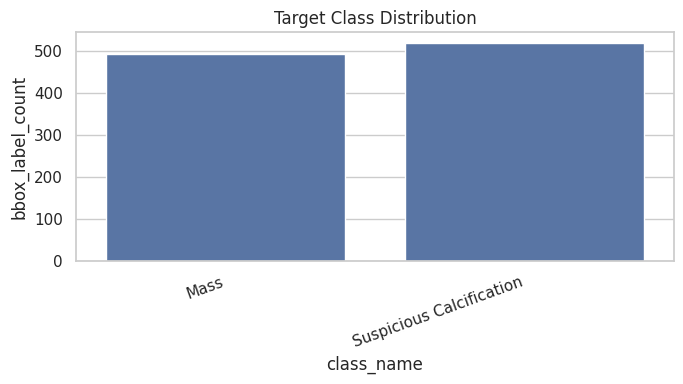

<Figure size 700x400 with 0 Axes>

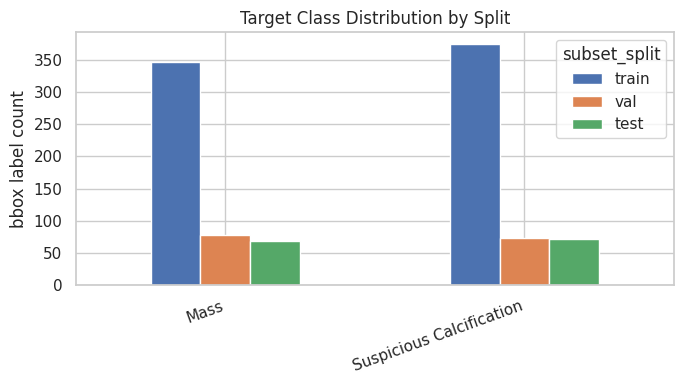

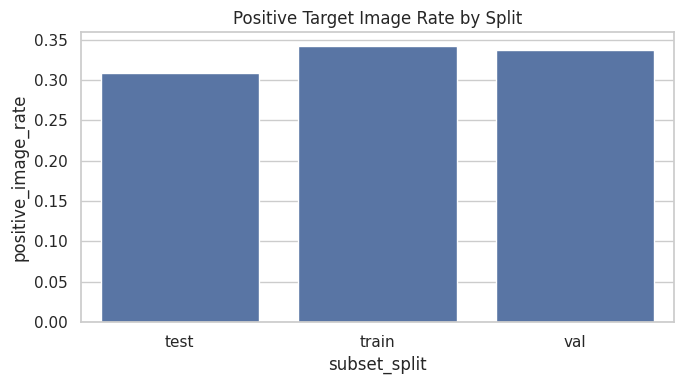

In [ ]:
# ------------------------------------------------------------
# 13. Grafikler
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
sns.barplot(data=class_distribution, x="class_name", y="bbox_label_count")
plt.title("Target Class Distribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_class_distribution.png", dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(7, 4))
class_by_split_table[["train", "val", "test"]].plot(kind="bar", figsize=(7, 4))
plt.title("Target Class Distribution by Split")
plt.xlabel("")
plt.ylabel("bbox label count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_class_distribution_by_split.png", dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(7, 4))
sns.barplot(data=split_summary, x="subset_split", y="positive_image_rate")
plt.title("Positive Target Image Rate by Split")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "positive_target_image_rate_by_split.png", dpi=180)
plt.show()
plt.close()


In [ ]:
# ------------------------------------------------------------
# 14. Rapor metni
# ------------------------------------------------------------

report_md = REPORT_DIR / f"{SUBSET_NAME}_DATASET_SELECTION_REPORT.md"

report_text = f"""# VinDr-Mammo 2-Class Target Subset Report

## Purpose

This subset was created as if the project had been designed from the beginning as a two-class mammography object detection task.

Target classes:

- Mass
- Suspicious Calcification

## Selection Strategy

The subset includes:

1. All selected studies containing at least one target finding: Mass or Suspicious Calcification.
2. Hard negative studies containing other findings but no target finding.
3. Normal negative studies without target findings.

Study-level splitting was used to avoid data leakage between train, validation, and test sets.

## Paths

- Subset directory: `{SUBSET_DIR}`
- Drive raw DICOM directory: `{DRIVE_RAW_DIR}`
- Local raw DICOM directory: `{LOCAL_RAW_DIR}`
- Manifest: `{manifest_path}`
- URL list: `{url_path}`

## Configuration

- Target classes: {TARGET_CLASSES}
- Negative study ratio: {NEGATIVE_STUDY_RATIO}
- Hard negative fraction: {HARD_NEGATIVE_FRACTION}
- Max target-positive studies: {MAX_TARGET_POSITIVE_STUDIES}
- Max total selected studies: {MAX_TOTAL_SELECTED_STUDIES}
- Train ratio: {TRAIN_RATIO}
- Validation ratio: {VAL_RATIO}
- Test ratio: {TEST_RATIO}
- Seed: {SEED}

## Split Summary

{split_summary.to_markdown(index=False)}

## Target Class Distribution

{class_distribution.to_markdown(index=False)}

## Target Class Distribution by Split

{class_by_split_table.reset_index().to_markdown(index=False)}

## Target BBox Multi-label Summary

{bbox_multilabel_summary.to_markdown(index=False)}

## BBox Stats

```json
{json.dumps(bbox_stats_summary, indent=2, ensure_ascii=False)}
Notes
This dataset is more appropriate for a focused two-class detection study than the previous 10-class subset.
Non-target findings are not used as detection labels, but studies/images containing non-target findings can be included as hard negatives.
The raw DICOM images are downloaded first to local Colab storage and periodically synchronized to Google Drive.
The dataset can later be converted into raw PNG, crop+CLAHE PNG, and patch/tile-based training sets.
"""

report_md.write_text(report_text, encoding="utf-8")

print("Report saved:", report_md)

Report saved: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_audit/reports/target2class_subset_v2_medium_balanced_DATASET_SELECTION_REPORT.md


In [ ]:
import pydicom

#------------------------------------------------------------
# 15. Indirme yardimcilari
#------------------------------------------------------------

def expected_relative_path_from_url(url):
    marker = "/files/vindr-mammo/1.0.0/"
    if marker not in url:
        raise ValueError(f"Beklenmeyen URL formati: {url}")
    return url.split(marker, 1)[1]

def local_path_from_url(url):
    return LOCAL_RAW_DIR / expected_relative_path_from_url(url)

def drive_path_from_url(url):
    return DRIVE_RAW_DIR / expected_relative_path_from_url(url)

def is_probably_valid_dicom(path):
    path = Path(path)

    if not path.exists():
        return False

    if path.stat().st_size < MIN_VALID_DICOM_SIZE_BYTES:
        return False

    try:
        _ = pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
        return True
    except Exception:
        return False

def write_urls(path, urls_to_write):
    Path(path).write_text("\n".join(urls_to_write), encoding="utf-8")

def sync_local_raw_to_drive():
    LOCAL_RAW_DIR.mkdir(parents=True, exist_ok=True)
    DRIVE_RAW_DIR.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-ah",
        "--info=progress2",
        f"{LOCAL_RAW_DIR}/",
        f"{DRIVE_RAW_DIR}/",
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0:
        print("rsync stdout:")
        print(result.stdout[-2000:])
        print("rsync stderr:")
        print(result.stderr[-4000:])
        raise RuntimeError("Local raw DICOM klasoru Drive'a senkronize edilemedi.")

    print("Local raw DICOM klasoru Drive'a senkronize edildi.")

In [ ]:
##------------------------------------------------------------
# 16. Ä°ndirme Ã¶ncesi durum kontrolÃ¼
#------------------------------------------------------------

urls = [u.strip() for u in url_path.read_text().splitlines() if u.strip()]
urls = list(dict.fromkeys(urls))

status_rows_before = []

for url in tqdm(urls, desc="Checking existing DICOM status"):
    lp = local_path_from_url(url)
    dp = drive_path_from_url(url)

    status_rows_before.append({
        "url": url,
        "relative_path": expected_relative_path_from_url(url),
        "local_path": str(lp),
        "drive_path": str(dp),
        "local_exists": lp.exists(),
        "drive_exists": dp.exists(),
        "local_size_bytes": lp.stat().st_size if lp.exists() else 0,
        "drive_size_bytes": dp.stat().st_size if dp.exists() else 0,
        "local_valid": is_probably_valid_dicom(lp),
        "drive_valid": is_probably_valid_dicom(dp),
    })

status_before_df = pd.DataFrame(status_rows_before)
status_before_df.to_csv(TABLE_DIR / "dicom_download_status_before.csv", index=False)

n_already_available = int((status_before_df["local_valid"] | status_before_df["drive_valid"]).sum())
n_missing = len(status_before_df) - n_already_available

download_summary_before = {
    "expected_dicom_count": len(status_before_df),
    "already_available_local_or_drive": n_already_available,
    "missing_or_invalid": n_missing,
    "drive_available_count": int(status_before_df["drive_valid"].sum()),
    "local_available_count": int(status_before_df["local_valid"].sum()),
    "drive_available_size_gb": round(status_before_df.loc[status_before_df["drive_valid"], "drive_size_bytes"].sum() / (1024 ** 3), 3),
    "local_available_size_gb": round(status_before_df.loc[status_before_df["local_valid"], "local_size_bytes"].sum() / (1024 ** 3), 3),
}

with open(TABLE_DIR / "dicom_download_summary_before.json", "w", encoding="utf-8") as f:
    json.dump(download_summary_before, f, indent=4, ensure_ascii=False)

print("Download summary before:")
print(json.dumps(download_summary_before, indent=2, ensure_ascii=False))

# KullanÄ±cÄ±ya indirme boyutu hakkÄ±nda kÄ±sa kontrol

print("\nSeçilen görüntü sayısı", len(urls))
print("Eksik/bozuk DICOM sayısı:", n_missing)

Checking existing DICOM status:   0%|          | 0/2040 [00:00<?, ?it/s]

Download summary before:
{
  "expected_dicom_count": 2040,
  "already_available_local_or_drive": 1622,
  "missing_or_invalid": 418,
  "drive_available_count": 1622,
  "local_available_count": 0,
  "drive_available_size_gb": 28.851,
  "local_available_size_gb": 0.0
}

Seçilen görüntü sayısı 2040
Eksik/bozuk DICOM sayısı: 418


In [ ]:
#------------------------------------------------------------
# 17. DICOM indirme - once /content, sonra periyodik Drive sync
#------------------------------------------------------------

RUN_DOWNLOAD = True  # Indirmeye hazir olunca True yap.
DOWNLOAD_MODE = "local_first_batch_wget"
MAX_FILES_PER_RUN = None  # Ornek: 200 yaparsan tek calistirmada sadece ilk 200 eksigi indirir.
SYNC_EVERY_N_COMPLETED = 30
PROGRESS_REFRESH_SECONDS = 30
LOG_WGET_TO_DRIVE = False

if RUN_DOWNLOAD:
    import time

    print("\nDICOM indirme baslayacak.")
    print("PhysioNet hesabinin VinDr-Mammo kullanim kosullarini onaylamis olmasi gerekir.")

    physionet_username = input("PhysioNet username: ").strip()
    physionet_password = getpass("PhysioNet password: ")

    urls_need_drive = []
    urls_to_download = []

    for url in urls:
        local_path = local_path_from_url(url)
        drive_path = drive_path_from_url(url)

        if is_probably_valid_dicom(drive_path):
            continue

        urls_need_drive.append(url)

        if not is_probably_valid_dicom(local_path):
            urls_to_download.append(url)

    urls_need_drive = list(dict.fromkeys(urls_need_drive))
    urls_to_download = list(dict.fromkeys(urls_to_download))

    if MAX_FILES_PER_RUN is not None:
        urls_to_download = urls_to_download[:MAX_FILES_PER_RUN]
        limited = set(urls_to_download)
        already_local_need_sync = [
            u for u in urls_need_drive
            if u not in limited and is_probably_valid_dicom(local_path_from_url(u))
        ]
        urls_need_drive = list(dict.fromkeys(already_local_need_sync + urls_to_download))

    urls_this_run_path = SUBSET_DIR / "dicom_urls_this_run.txt"
    write_urls(urls_this_run_path, urls_to_download)

    tracked_local_paths = [local_path_from_url(u) for u in urls_need_drive]
    expected_download_paths = [local_path_from_url(u) for u in urls_to_download]

    print("Toplam URL:", len(urls))
    print("Drive'da zaten mevcut/gecerli:", len(urls) - len(urls_need_drive))
    print("Local'de olup Drive'a kopyalanacak veya yeni indirilecek:", len(urls_need_drive))
    print("Bu calistirmada /content'e indirilecek DICOM sayisi:", len(urls_to_download))
    print("Local hedef:", LOCAL_RAW_DIR)
    print("Drive hedef:", DRIVE_RAW_DIR)
    print("Indirme modu:", DOWNLOAD_MODE)
    print("URL listesi:", urls_this_run_path)
    print("Sync araligi:", SYNC_EVERY_N_COMPLETED, "tamamlanan/gecerli local dosya")

    if len(urls_need_drive) == 0:
        print("Eksik DICOM gorunmuyor. Indirme ve sync atlandi.")
    elif len(urls_to_download) == 0:
        print("Yeni indirilecek dosya yok; localdeki gecerli dosyalar Drive'a kopyalaniyor.")
        sync_local_raw_to_drive()
    elif DOWNLOAD_MODE == "local_first_batch_wget":
        log_path = (
            SUBSET_DIR / "wget_dicom_download.log"
            if LOG_WGET_TO_DRIVE
            else Path("/content") / f"wget_{SUBSET_NAME}_dicom_download.log"
        )

        print("Wget log dosyasi:", log_path)
        print("Not: Wget ciktilari log dosyasina yaziliyor; ekranda periyodik ilerleme ozeti gosterilecek.")
        print("Resume: wget -c aktif. Hucre tekrar calistirilirse /content'teki yarim dosyalardan devam eder.")
        print("Checkpoint: Her", SYNC_EVERY_N_COMPLETED, "tamamlanan/gecerli local dosyada Drive'a rsync yapilir.")

        cmd = [
            "wget",
            "--user", physionet_username,
            "--password", physionet_password,
            "-c",
            "-i", str(urls_this_run_path),
            "-x",
            "-nH",
            "--cut-dirs=3",
            "--tries=3",
            "--timeout=60",
            "--read-timeout=60",
            "--output-file", str(log_path),
            "-P", str(LOCAL_RAW_DIR),
        ]

        process = subprocess.Popen(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

        start_time = time.time()
        last_done = -1
        last_synced_done = 0

        while process.poll() is None:
            done = sum(p.exists() and p.stat().st_size >= MIN_VALID_DICOM_SIZE_BYTES for p in tracked_local_paths)
            downloaded_now = sum(p.exists() and p.stat().st_size >= MIN_VALID_DICOM_SIZE_BYTES for p in expected_download_paths)
            elapsed_min = (time.time() - start_time) / 60

            if done != last_done:
                print(
                    f"[{elapsed_min:6.1f} dk] Local tamamlanan/var olan: {done}/{len(tracked_local_paths)} "
                    f"| bu calistirmada indirilen: {downloaded_now}/{len(expected_download_paths)}",
                    flush=True,
                )
                last_done = done

            if done - last_synced_done >= SYNC_EVERY_N_COMPLETED:
                print(f"\n{done} local dosya tamamlandi/gecerli. Drive'a senkronize ediliyor...", flush=True)
                sync_local_raw_to_drive()
                last_synced_done = done

            time.sleep(PROGRESS_REFRESH_SECONDS)

        return_code = process.wait()
        done = sum(p.exists() and p.stat().st_size >= MIN_VALID_DICOM_SIZE_BYTES for p in tracked_local_paths)
        downloaded_now = sum(p.exists() and p.stat().st_size >= MIN_VALID_DICOM_SIZE_BYTES for p in expected_download_paths)
        elapsed_min = (time.time() - start_time) / 60

        print(
            f"[{elapsed_min:6.1f} dk] Batch wget bitti. "
            f"Local tamamlanan/var olan: {done}/{len(tracked_local_paths)} "
            f"| bu calistirmada indirilen: {downloaded_now}/{len(expected_download_paths)}"
        )

        print("Final Drive senkronizasyonu yapiliyor...")
        sync_local_raw_to_drive()

        if return_code != 0:
            print("Wget hata kodu:", return_code)
            print("Son log satirlari:")
            if log_path.exists():
                tail = log_path.read_text(errors="ignore").splitlines()[-40:]
                print("\n".join(tail))
            raise subprocess.CalledProcessError(return_code, cmd)

        print("Indirme ve Drive sync tamamlandi. Simdi indirme sonrasi kontrol hucrelerini calistir.")
    else:
        raise ValueError(f"Bilinmeyen DOWNLOAD_MODE: {DOWNLOAD_MODE}")
else:
    print("RUN_DOWNLOAD=False oldugu icin DICOM indirme atlandi.")


DICOM indirme baslayacak.
PhysioNet hesabinin VinDr-Mammo kullanim kosullarini onaylamis olmasi gerekir.
Toplam URL: 2040
Drive'da zaten mevcut/gecerli: 1622
Local'de olup Drive'a kopyalanacak veya yeni indirilecek: 418
Bu calistirmada /content'e indirilecek DICOM sayisi: 417
Local hedef: /content/vindr_mammo_fast_raw/target2class_subset_v2_medium_balanced
Drive hedef: /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced
Indirme modu: local_first_batch_wget
URL listesi: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/dicom_urls_this_run.txt
Sync araligi: 30 tamamlanan/gecerli local dosya
Wget log dosyasi: /content/wget_target2class_subset_v2_medium_balanced_dicom_download.log
Not: Wget ciktilari log dosyasina yaziliyor; ekranda periyodik ilerleme ozeti gosterilecek.
Resume: wget -c aktif. Hucre tekrar calistirilirse /content'teki yarim dosyalardan devam eder.
Checkpoint: Her 30 tamamlanan/gecerli local dosyada 

In [ ]:
#------------------------------------------------------------
# 18. Indirme sonrasi kontrol
#------------------------------------------------------------

status_rows_after = []

for url in tqdm(urls, desc="Final DICOM status check"):
    lp = local_path_from_url(url)
    dp = drive_path_from_url(url)

    local_valid = is_probably_valid_dicom(lp)
    drive_valid = is_probably_valid_dicom(dp)

    status_rows_after.append({
        "url": url,
        "relative_path": expected_relative_path_from_url(url),
        "local_path": str(lp),
        "drive_path": str(dp),
        "local_exists": lp.exists(),
        "drive_exists": dp.exists(),
        "local_size_bytes": lp.stat().st_size if lp.exists() else 0,
        "drive_size_bytes": dp.stat().st_size if dp.exists() else 0,
        "local_valid": local_valid,
        "drive_valid": drive_valid,
        "available_local_or_drive": local_valid or drive_valid,
    })

status_after_df = pd.DataFrame(status_rows_after)
status_after_df.to_csv(TABLE_DIR / "dicom_download_status_after.csv", index=False)

missing_after = status_after_df[~status_after_df["available_local_or_drive"]].copy()
missing_after.to_csv(TABLE_DIR / "missing_dicom_after_download.csv", index=False)

missing_after["url"].to_csv(
    SUBSET_DIR / "missing_dicom_urls_after_download.txt",
    index=False,
    header=False
)

download_summary_after = {
    "expected_dicom_count": int(len(status_after_df)),
    "available_local_or_drive": int(status_after_df["available_local_or_drive"].sum()),
    "available_in_drive": int(status_after_df["drive_valid"].sum()),
    "available_in_local": int(status_after_df["local_valid"].sum()),
    "missing_after": int(len(missing_after)),
    "drive_available_size_gb": round(status_after_df.loc[status_after_df["drive_valid"], "drive_size_bytes"].sum() / (1024 ** 3), 3),
    "local_available_size_gb": round(status_after_df.loc[status_after_df["local_valid"], "local_size_bytes"].sum() / (1024 ** 3), 3),
}

with open(TABLE_DIR / "dicom_download_summary_after.json", "w", encoding="utf-8") as f:
    json.dump(download_summary_after, f, indent=4, ensure_ascii=False)

print("Download summary after:")
print(json.dumps(download_summary_after, indent=2, ensure_ascii=False))

Final DICOM status check:   0%|          | 0/2040 [00:00<?, ?it/s]

Download summary after:
{
  "expected_dicom_count": 2040,
  "available_local_or_drive": 2040,
  "available_in_drive": 2040,
  "available_in_local": 418,
  "missing_after": 0,
  "drive_available_size_gb": 34.678,
  "local_available_size_gb": 5.827
}


In [ ]:
#------------------------------------------------------------
#19. Final raporu gÃ¼ncelle
#------------------------------------------------------------

final_report_path = REPORT_DIR / f"{SUBSET_NAME}_FINAL_DOWNLOAD_REPORT.md"

final_report_text = f"""# VinDr-Mammo 2-Class Target Subset Final Download Report

Subset
Subset name: {SUBSET_NAME}
Target classes:
Mass
Suspicious Calcification
Selection Summary
Selected studies: {len(selected_study_ids)}
Selected images / expected DICOM files: {len(urls)}
Manifest path: {manifest_path}
URL list: {url_path}
Split Summary

{split_summary.to_markdown(index=False)}

Target Class Distribution

{class_distribution.to_markdown(index=False)}

Target Class Distribution by Split

{class_by_split_table.reset_index().to_markdown(index=False)}

Download Summary Before
{json.dumps(download_summary_before, indent=2, ensure_ascii=False)}
Download Summary After
{json.dumps(download_summary_after, indent=2, ensure_ascii=False)}
Important Paths
Subset directory: {SUBSET_DIR}
Audit directory: {AUDIT_DIR}
Tables: {TABLE_DIR}
Figures: {FIGURE_DIR}
Reports: {REPORT_DIR}
Local raw DICOM directory: {LOCAL_RAW_DIR}
Drive raw DICOM directory: {DRIVE_RAW_DIR}
Notes

This subset was created for a focused two-class object detection study. It is suitable for the following next steps:

Raw image 2-class YOLOv8 baseline.
Crop + CLAHE 2-class YOLOv8 baseline.
RetinaNet and Faster R-CNN on the same 2-class data.
Confidence/NMS threshold optimization.
High-resolution or patch/tile-based training experiments.
"""

final_report_path.write_text(final_report_text, encoding="utf-8")

print("Final report saved:", final_report_path)

print("\n" + "=" * 90)
print("2-CLASS TARGET SUBSET SELECTION + DOWNLOAD PIPELINE COMPLETED")
print("=" * 90)
print("Subset:", SUBSET_DIR)
print("Raw DICOM Drive:", DRIVE_RAW_DIR)
print("Final report:", final_report_path)
print("Missing after download:", len(missing_after))

Final report saved: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_audit/reports/target2class_subset_v2_medium_balanced_FINAL_DOWNLOAD_REPORT.md

2-CLASS TARGET SUBSET SELECTION + DOWNLOAD PIPELINE COMPLETED
Subset: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced
Raw DICOM Drive: /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced
Final report: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_audit/reports/target2class_subset_v2_medium_balanced_FINAL_DOWNLOAD_REPORT.md
Missing after download: 0


In [ ]:
# ============================================================
# VinDr-Mammo target2class_subset_v2_medium_balanced
# DICOM -> PNG + Raw Dataset + Crop/CLAHE Dataset + EDA
#
# Target classes:
#   0: Mass
#   1: Suspicious Calcification
#
# Same-box multi-label handling:
#   If same bbox has both Mass and Suspicious Calcification,
#   primary label = Mass
#
# Outputs:
#   1) raw PNG prepared dataset
#   2) crop + CLAHE prepared dataset
#   3) YOLO labels
#   4) COCO annotations
#   5) EDA tables, figures, visual checks, reports
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

!pip -q install pandas numpy matplotlib seaborn opencv-python pydicom tqdm pyyaml openpyxl

from pathlib import Path
from datetime import datetime
import os
import json
import shutil
import subprocess
import random
import warnings

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. Genel ayarlar
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/content/drive/MyDrive/vindr_mammo")
DATASET_BASE = PROJECT_ROOT / "dataset"

SUBSET_NAME = "target2class_subset_v2_medium_balanced"

SUBSET_DIR = DATASET_BASE / "subsets" / SUBSET_NAME
DRIVE_RAW_DICOM_DIR = DATASET_BASE / "raw" / SUBSET_NAME
LOCAL_RAW_DICOM_DIR = Path("/content/vindr_mammo_fast_raw") / SUBSET_NAME

LOCAL_PREPARED_BASE = Path("/content/vindr_prepared_datasets")
DRIVE_PREPARED_BASE = DATASET_BASE / "prepared_datasets"

RAW_DATASET_NAME = f"{SUBSET_NAME}_raw_png_2class"
CROP_CLAHE_DATASET_NAME = f"{SUBSET_NAME}_crop_clahe_2class"

LOCAL_RAW_PREPARED_DIR = LOCAL_PREPARED_BASE / RAW_DATASET_NAME
DRIVE_RAW_PREPARED_DIR = DRIVE_PREPARED_BASE / RAW_DATASET_NAME

LOCAL_CROP_PREPARED_DIR = LOCAL_PREPARED_BASE / CROP_CLAHE_DATASET_NAME
DRIVE_CROP_PREPARED_DIR = DRIVE_PREPARED_BASE / CROP_CLAHE_DATASET_NAME

MANIFEST_PATH = SUBSET_DIR / "subset_manifest.csv"
TARGET_FINDINGS_EXPLODED_PATH = SUBSET_DIR / "target_findings_exploded.csv"

TARGET_CLASSES = ["Mass", "Suspicious Calcification"]
CLASS_NAME_TO_ID = {
    "Mass": 0,
    "Suspicious Calcification": 1,
}
ID_TO_CLASS_NAME = {
    0: "Mass",
    1: "Suspicious Calcification",
}

# Aynı bbox hem Mass hem Calcification ise Mass seçilecek.
PRIMARY_PRIORITY = ["Mass", "Suspicious Calcification"]

# DICOM -> PNG ayarları
MAX_SIDE = 2048
LOW_PERCENTILE = 0.5
HIGH_PERCENTILE = 99.5

# Crop + CLAHE ayarları
CREATE_CROP_CLAHE_DATASET = True
CROP_MARGIN_RATIO = 0.035
MIN_BREAST_AREA_RATIO = 0.05
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# Sync ayarı
SYNC_EVERY_N_IMAGES = 100

# Yeniden oluşturma ayarları
FORCE_REBUILD_RAW = False
FORCE_REBUILD_CROP_CLAHE = False

print("SUBSET_DIR:", SUBSET_DIR)
print("DRIVE_RAW_DICOM_DIR:", DRIVE_RAW_DICOM_DIR)
print("LOCAL_RAW_DICOM_DIR:", LOCAL_RAW_DICOM_DIR)
print("DRIVE_RAW_PREPARED_DIR:", DRIVE_RAW_PREPARED_DIR)
print("DRIVE_CROP_PREPARED_DIR:", DRIVE_CROP_PREPARED_DIR)

for p in [SUBSET_DIR, DRIVE_RAW_DICOM_DIR, MANIFEST_PATH, TARGET_FINDINGS_EXPLODED_PATH]:
    print(p, "exists:", p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

# ------------------------------------------------------------
# 2. Drive'daki DICOM'ları local /content'e kopyala
# ------------------------------------------------------------

def rsync_dir(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-ah",
        "--info=progress2",
        f"{src}/",
        f"{dst}/"
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr[-4000:])
        raise RuntimeError(f"rsync başarısız: {src} -> {dst}")

    print(f"✅ Synced: {src} -> {dst}")

print("DICOM dosyaları Drive'dan local /content'e senkronize ediliyor...")
rsync_dir(DRIVE_RAW_DICOM_DIR, LOCAL_RAW_DICOM_DIR)

# ------------------------------------------------------------
# 3. Manifest ve annotation dosyalarını oku
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)
target_findings = pd.read_csv(TARGET_FINDINGS_EXPLODED_PATH)

manifest["study_id"] = manifest["study_id"].astype(str)
manifest["image_id"] = manifest["image_id"].astype(str)

target_findings["study_id"] = target_findings["study_id"].astype(str)
target_findings["image_id"] = target_findings["image_id"].astype(str)

for col in ["xmin", "ymin", "xmax", "ymax"]:
    target_findings[col] = pd.to_numeric(target_findings[col], errors="coerce")

target_findings = target_findings[
    target_findings["category_list"].isin(TARGET_CLASSES)
].copy()

selected_image_ids = set(manifest["image_id"].astype(str))
target_findings = target_findings[
    target_findings["image_id"].isin(selected_image_ids)
].copy()

print("Manifest:", manifest.shape)
print("Target findings exploded:", target_findings.shape)
display(manifest.head())
display(target_findings.head())

# ------------------------------------------------------------
# 4. Multi-label bbox -> primary 2-class annotation
# ------------------------------------------------------------

bbox_key_cols = ["study_id", "image_id", "xmin", "ymin", "xmax", "ymax"]

def choose_primary_class(classes):
    classes = list(sorted(set(classes)))
    for c in PRIMARY_PRIORITY:
        if c in classes:
            return c
    return classes[0]

primary_rows = []

for key, group in target_findings.groupby(bbox_key_cols, dropna=False):
    class_list = sorted(set(group["category_list"].tolist()))
    primary_class = choose_primary_class(class_list)

    row = dict(zip(bbox_key_cols, key))
    row["target_classes_same_box"] = "|".join(class_list)
    row["n_target_classes_same_box"] = len(class_list)
    row["primary_class_name"] = primary_class
    row["primary_class_id"] = CLASS_NAME_TO_ID[primary_class]
    primary_rows.append(row)

primary_ann = pd.DataFrame(primary_rows)

primary_ann = primary_ann.merge(
    manifest[["image_id", "subset_split"]].drop_duplicates(),
    on="image_id",
    how="left"
)

if primary_ann["subset_split"].isna().any():
    raise RuntimeError("Bazı annotation satırları split alamadı.")

print("Exploded target labels:", len(target_findings))
print("Unique primary bboxes:", len(primary_ann))
print("Primary class distribution:")
display(primary_ann["primary_class_name"].value_counts().rename_axis("class_name").reset_index(name="count"))

multi_label_summary = (
    primary_ann["n_target_classes_same_box"]
    .value_counts()
    .sort_index()
    .rename_axis("n_target_classes_same_box")
    .reset_index(name="bbox_count")
)

display(multi_label_summary)

# ------------------------------------------------------------
# 5. Yardımcı fonksiyonlar
# ------------------------------------------------------------

def valid_dicom_path(row):
    rel = row.get("expected_relative_path", None)

    if isinstance(rel, str) and rel.strip():
        local_path = LOCAL_RAW_DICOM_DIR / rel
        drive_path = DRIVE_RAW_DICOM_DIR / rel
    else:
        local_path = LOCAL_RAW_DICOM_DIR / "images" / str(row["study_id"]) / f"{row['image_id']}.dicom"
        drive_path = DRIVE_RAW_DICOM_DIR / "images" / str(row["study_id"]) / f"{row['image_id']}.dicom"

    if local_path.exists() and local_path.stat().st_size > 1024:
        return local_path, "local"

    if drive_path.exists() and drive_path.stat().st_size > 1024:
        return drive_path, "drive"

    return local_path, "missing"


def dicom_to_uint8_png_array(dicom_path):
    ds = pydicom.dcmread(str(dicom_path), force=True)

    try:
        arr = apply_voi_lut(ds.pixel_array, ds)
    except Exception:
        arr = ds.pixel_array

    arr = np.asarray(arr)

    if arr.ndim > 2:
        arr = np.squeeze(arr)
        if arr.ndim > 2:
            arr = arr[0]

    arr = arr.astype(np.float32)

    photometric = str(getattr(ds, "PhotometricInterpretation", "")).upper()

    if photometric == "MONOCHROME1":
        arr = arr.max() - arr

    finite_mask = np.isfinite(arr)
    if not finite_mask.any():
        raise RuntimeError(f"Geçersiz pixel array: {dicom_path}")

    arr_valid = arr[finite_mask]

    lo = np.percentile(arr_valid, LOW_PERCENTILE)
    hi = np.percentile(arr_valid, HIGH_PERCENTILE)

    if hi <= lo:
        lo = arr_valid.min()
        hi = arr_valid.max()

    if hi <= lo:
        arr8 = np.zeros_like(arr, dtype=np.uint8)
    else:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
        arr8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

    return arr8, ds


def resize_keep_aspect(img, max_side=2048):
    h, w = img.shape[:2]
    scale = min(max_side / max(h, w), 1.0)

    if scale == 1.0:
        return img, 1.0, 1.0

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    scale_x = new_w / w
    scale_y = new_h / h

    return resized, scale_x, scale_y


def clip_box(x1, y1, x2, y2, w, h):
    x1 = max(0.0, min(float(x1), w - 1))
    y1 = max(0.0, min(float(y1), h - 1))
    x2 = max(0.0, min(float(x2), w - 1))
    y2 = max(0.0, min(float(y2), h - 1))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def xyxy_to_yolo(x1, y1, x2, y2, w, h):
    bw = x2 - x1
    bh = y2 - y1

    if bw <= 1 or bh <= 1:
        return None

    xc = x1 + bw / 2
    yc = y1 + bh / 2

    return xc / w, yc / h, bw / w, bh / h


def yolo_to_xyxy(cls, xc, yc, bw, bh, w, h):
    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h
    return x1, y1, x2, y2


def write_yolo_label(path, labels):
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    for lab in labels:
        lines.append(
            f"{int(lab['class_id'])} {lab['xc']:.8f} {lab['yc']:.8f} {lab['bw']:.8f} {lab['bh']:.8f}"
        )

    with open(path, "w", encoding="utf-8") as f:
        if lines:
            f.write("\n".join(lines) + "\n")


def read_yolo_label(path):
    path = Path(path)

    if not path.exists():
        return []

    txt = path.read_text().strip()

    if not txt:
        return []

    labels = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])
        labels.append({
            "class_id": cls,
            "xc": xc,
            "yc": yc,
            "bw": bw,
            "bh": bh,
        })

    return labels


def make_data_yaml(prepared_dir):
    data_yaml = {
        "path": str(prepared_dir),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": 2,
        "names": {
            0: "Mass",
            1: "Suspicious Calcification",
        },
    }

    with open(prepared_dir / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)


def make_class_mapping(prepared_dir):
    mapping = {
        "class_to_id": CLASS_NAME_TO_ID,
        "id_to_class": {str(k): v for k, v in ID_TO_CLASS_NAME.items()},
        "primary_priority": PRIMARY_PRIORITY,
        "same_box_multilabel_rule": "Mass priority if same bbox has Mass and Suspicious Calcification",
    }

    with open(prepared_dir / "class_mapping.json", "w", encoding="utf-8") as f:
        json.dump(mapping, f, indent=4, ensure_ascii=False)


def sync_prepared_to_drive(local_prepared_dir, drive_prepared_dir):
    drive_prepared_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-ah",
        "--info=progress2",
        f"{local_prepared_dir}/",
        f"{drive_prepared_dir}/"
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr[-4000:])
        raise RuntimeError("Prepared dataset sync başarısız.")

    print(f"✅ Prepared synced: {local_prepared_dir} -> {drive_prepared_dir}")


# ------------------------------------------------------------
# 6. Raw PNG prepared dataset oluştur
# ------------------------------------------------------------

def prepare_raw_png_dataset():
    ready_flag = DRIVE_RAW_PREPARED_DIR / "RAW_PNG_DATASET_READY.flag"

    if ready_flag.exists() and not FORCE_REBUILD_RAW:
        print("✅ Raw PNG dataset zaten hazır. Atlanıyor.")
        return

    print("🚀 Raw PNG 2-class dataset hazırlanıyor...")

    if FORCE_REBUILD_RAW:
        shutil.rmtree(LOCAL_RAW_PREPARED_DIR, ignore_errors=True)
        shutil.rmtree(DRIVE_RAW_PREPARED_DIR, ignore_errors=True)

    for base in [LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR]:
        for sub in [
            "images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test",
            "annotations", "logs", "eda/tables", "eda/figures", "visual_checks"
        ]:
            (base / sub).mkdir(parents=True, exist_ok=True)

    conversion_rows = []
    failed_rows = []
    dropped_box_rows = []

    ann_by_image = {
        image_id: group.copy()
        for image_id, group in primary_ann.groupby("image_id")
    }

    coco_by_split = {
        "train": {"images": [], "annotations": [], "categories": []},
        "val": {"images": [], "annotations": [], "categories": []},
        "test": {"images": [], "annotations": [], "categories": []},
    }

    categories = [
        {"id": 1, "name": "Mass", "supercategory": "finding"},
        {"id": 2, "name": "Suspicious Calcification", "supercategory": "finding"},
    ]

    for split in ["train", "val", "test"]:
        coco_by_split[split]["categories"] = categories

    image_id_counter = {"train": 1, "val": 1, "test": 1}
    ann_id_counter = {"train": 1, "val": 1, "test": 1}

    manifest_sorted = manifest.sort_values(["subset_split", "study_id", "image_id"]).reset_index(drop=True)

    converted_count = 0

    for _, row in tqdm(manifest_sorted.iterrows(), total=len(manifest_sorted), desc="DICOM -> raw PNG"):
        split = row["subset_split"]
        study_id = str(row["study_id"])
        image_id = str(row["image_id"])

        dicom_path, source_location = valid_dicom_path(row)

        out_img_path = LOCAL_RAW_PREPARED_DIR / "images" / split / f"{image_id}.png"
        out_lbl_path = LOCAL_RAW_PREPARED_DIR / "labels" / split / f"{image_id}.txt"

        try:
            if source_location == "missing":
                raise FileNotFoundError(f"DICOM missing: {dicom_path}")

            img8, ds = dicom_to_uint8_png_array(dicom_path)
            orig_h, orig_w = img8.shape[:2]

            resized, scale_x, scale_y = resize_keep_aspect(img8, MAX_SIDE)
            new_h, new_w = resized.shape[:2]

            out_img_path.parent.mkdir(parents=True, exist_ok=True)
            ok = cv2.imwrite(str(out_img_path), resized)

            if not ok:
                raise IOError(f"PNG yazılamadı: {out_img_path}")

            labels = []
            anns_img = ann_by_image.get(image_id, pd.DataFrame())

            coco_image_id = image_id_counter[split]
            image_id_counter[split] += 1

            coco_by_split[split]["images"].append({
                "id": coco_image_id,
                "file_name": f"images/{split}/{image_id}.png",
                "width": int(new_w),
                "height": int(new_h),
                "study_id": study_id,
                "original_image_id": image_id,
            })

            for _, ann in anns_img.iterrows():
                x1 = ann["xmin"] * scale_x
                y1 = ann["ymin"] * scale_y
                x2 = ann["xmax"] * scale_x
                y2 = ann["ymax"] * scale_y

                clipped = clip_box(x1, y1, x2, y2, new_w, new_h)

                if clipped is None:
                    dropped_box_rows.append({
                        "study_id": study_id,
                        "image_id": image_id,
                        "split": split,
                        "reason": "invalid_after_resize_clip",
                        "class_name": ann["primary_class_name"],
                        "xmin": ann["xmin"],
                        "ymin": ann["ymin"],
                        "xmax": ann["xmax"],
                        "ymax": ann["ymax"],
                    })
                    continue

                x1c, y1c, x2c, y2c = clipped
                yolo_box = xyxy_to_yolo(x1c, y1c, x2c, y2c, new_w, new_h)

                if yolo_box is None:
                    continue

                xc, yc, bw, bh = yolo_box
                class_id = int(ann["primary_class_id"])

                labels.append({
                    "class_id": class_id,
                    "xc": xc,
                    "yc": yc,
                    "bw": bw,
                    "bh": bh,
                })

                coco_ann_id = ann_id_counter[split]
                ann_id_counter[split] += 1

                coco_by_split[split]["annotations"].append({
                    "id": coco_ann_id,
                    "image_id": coco_image_id,
                    "category_id": class_id + 1,
                    "bbox": [float(x1c), float(y1c), float(x2c - x1c), float(y2c - y1c)],
                    "area": float((x2c - x1c) * (y2c - y1c)),
                    "iscrowd": 0,
                    "study_id": study_id,
                    "original_image_id": image_id,
                    "class_name": ID_TO_CLASS_NAME[class_id],
                })

            write_yolo_label(out_lbl_path, labels)

            conversion_rows.append({
                "study_id": study_id,
                "image_id": image_id,
                "split": split,
                "dicom_path": str(dicom_path),
                "source_location": source_location,
                "png_path": str(out_img_path),
                "orig_width": int(orig_w),
                "orig_height": int(orig_h),
                "new_width": int(new_w),
                "new_height": int(new_h),
                "scale_x": float(scale_x),
                "scale_y": float(scale_y),
                "n_labels": len(labels),
                "status": "success",
            })

            converted_count += 1

            if converted_count % SYNC_EVERY_N_IMAGES == 0:
                pd.DataFrame(conversion_rows).to_csv(
                    LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_conversion_log_live.csv",
                    index=False
                )
                sync_prepared_to_drive(LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR)

        except Exception as e:
            failed_rows.append({
                "study_id": study_id,
                "image_id": image_id,
                "split": split,
                "dicom_path": str(dicom_path),
                "source_location": source_location,
                "error": str(e),
            })

    conversion_df = pd.DataFrame(conversion_rows)
    failed_df = pd.DataFrame(failed_rows)
    dropped_df = pd.DataFrame(dropped_box_rows)

    conversion_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_conversion_log.csv", index=False)
    failed_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_failed_conversions.csv", index=False)
    dropped_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_dropped_boxes.csv", index=False)

    for split, coco in coco_by_split.items():
        with open(LOCAL_RAW_PREPARED_DIR / "annotations" / f"instances_{split}.json", "w", encoding="utf-8") as f:
            json.dump(coco, f, indent=2, ensure_ascii=False)

    primary_ann.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "primary_2class_annotations.csv", index=False)
    multi_label_summary.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "same_box_multilabel_summary.csv", index=False)

    make_data_yaml(LOCAL_RAW_PREPARED_DIR)
    make_class_mapping(LOCAL_RAW_PREPARED_DIR)

    sync_prepared_to_drive(LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR)

    (DRIVE_RAW_PREPARED_DIR / "RAW_PNG_DATASET_READY.flag").write_text(
        f"Raw PNG dataset created at {datetime.now().isoformat()}\n",
        encoding="utf-8"
    )

    print("Raw conversion success:", len(conversion_df))
    print("Raw conversion failed:", len(failed_df))

    if len(failed_df) > 0:
        display(failed_df.head())
        raise RuntimeError("Bazı DICOM dosyaları PNG'ye çevrilemedi. Log dosyasını kontrol et.")

prepare_raw_png_dataset()

# ------------------------------------------------------------
# 7. Crop + CLAHE dataset oluştur
# ------------------------------------------------------------

def find_breast_crop_box(gray):
    h, w = gray.shape[:2]

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    try:
        _, mask = cv2.threshold(
            blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
    except Exception:
        return 0, 0, w, h, "fallback_threshold_error"

    area_ratio = (mask > 0).sum() / (h * w)

    if area_ratio < MIN_BREAST_AREA_RATIO or area_ratio > 0.98:
        threshold_value = max(5, np.percentile(gray, 2))
        mask = (gray > threshold_value).astype(np.uint8) * 255

    kernel = np.ones((9, 9), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return 0, 0, w, h, "fallback_no_contour"

    largest = max(contours, key=cv2.contourArea)
    contour_area = cv2.contourArea(largest)

    if contour_area / (h * w) < MIN_BREAST_AREA_RATIO:
        return 0, 0, w, h, "fallback_small_contour"

    x, y, bw, bh = cv2.boundingRect(largest)

    margin_x = int(round(CROP_MARGIN_RATIO * w))
    margin_y = int(round(CROP_MARGIN_RATIO * h))

    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(w, x + bw + margin_x)
    y2 = min(h, y + bh + margin_y)

    if x2 <= x1 or y2 <= y1:
        return 0, 0, w, h, "fallback_invalid_crop"

    return x1, y1, x2, y2, "ok"


def apply_clahe(gray):
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE
    )
    return clahe.apply(gray)


def transform_labels_to_crop(labels, orig_w, orig_h, crop_box):
    crop_x1, crop_y1, crop_x2, crop_y2 = crop_box
    crop_w = crop_x2 - crop_x1
    crop_h = crop_y2 - crop_y1

    new_labels = []
    dropped = []

    for lab in labels:
        x1, y1, x2, y2 = yolo_to_xyxy(
            lab["class_id"],
            lab["xc"],
            lab["yc"],
            lab["bw"],
            lab["bh"],
            orig_w,
            orig_h
        )

        nx1 = x1 - crop_x1
        ny1 = y1 - crop_y1
        nx2 = x2 - crop_x1
        ny2 = y2 - crop_y1

        clipped = clip_box(nx1, ny1, nx2, ny2, crop_w, crop_h)

        if clipped is None:
            dropped.append({
                "class_id": lab["class_id"],
                "reason": "invalid_after_crop",
                "orig_xyxy": [x1, y1, x2, y2],
                "crop_box": crop_box,
            })
            continue

        x1c, y1c, x2c, y2c = clipped
        yolo_new = xyxy_to_yolo(x1c, y1c, x2c, y2c, crop_w, crop_h)

        if yolo_new is None:
            continue

        xc, yc, bw, bh = yolo_new

        new_labels.append({
            "class_id": lab["class_id"],
            "xc": min(max(xc, 0.0), 1.0),
            "yc": min(max(yc, 0.0), 1.0),
            "bw": min(max(bw, 0.0), 1.0),
            "bh": min(max(bh, 0.0), 1.0),
        })

    return new_labels, dropped


def make_coco_from_yolo(prepared_dir, split):
    image_dir = prepared_dir / "images" / split
    label_dir = prepared_dir / "labels" / split

    images = []
    annotations = []
    categories = [
        {"id": 1, "name": "Mass", "supercategory": "finding"},
        {"id": 2, "name": "Suspicious Calcification", "supercategory": "finding"},
    ]

    ann_id = 1

    for img_idx, image_path in enumerate(sorted(image_dir.glob("*.png")), start=1):
        image_id = image_path.stem
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        h, w = img.shape[:2]

        images.append({
            "id": img_idx,
            "file_name": f"images/{split}/{image_id}.png",
            "width": int(w),
            "height": int(h),
            "original_image_id": image_id,
        })

        labels = read_yolo_label(label_dir / f"{image_id}.txt")

        for lab in labels:
            x1, y1, x2, y2 = yolo_to_xyxy(
                lab["class_id"],
                lab["xc"],
                lab["yc"],
                lab["bw"],
                lab["bh"],
                w,
                h
            )

            clipped = clip_box(x1, y1, x2, y2, w, h)
            if clipped is None:
                continue

            x1c, y1c, x2c, y2c = clipped

            annotations.append({
                "id": ann_id,
                "image_id": img_idx,
                "category_id": int(lab["class_id"]) + 1,
                "bbox": [float(x1c), float(y1c), float(x2c - x1c), float(y2c - y1c)],
                "area": float((x2c - x1c) * (y2c - y1c)),
                "iscrowd": 0,
                "original_image_id": image_id,
                "class_name": ID_TO_CLASS_NAME[int(lab["class_id"])],
            })

            ann_id += 1

    return {
        "info": {
            "description": f"{prepared_dir.name} {split}",
            "created_at": datetime.now().isoformat(),
        },
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }


def prepare_crop_clahe_dataset():
    if not CREATE_CROP_CLAHE_DATASET:
        print("CREATE_CROP_CLAHE_DATASET=False. Atlanıyor.")
        return

    ready_flag = DRIVE_CROP_PREPARED_DIR / "CROP_CLAHE_DATASET_READY.flag"

    if ready_flag.exists() and not FORCE_REBUILD_CROP_CLAHE:
        print("✅ Crop+CLAHE dataset zaten hazır. Atlanıyor.")
        return

    print("🚀 Crop + CLAHE 2-class dataset hazırlanıyor...")

    if FORCE_REBUILD_CROP_CLAHE:
        shutil.rmtree(LOCAL_CROP_PREPARED_DIR, ignore_errors=True)
        shutil.rmtree(DRIVE_CROP_PREPARED_DIR, ignore_errors=True)

    for base in [LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR]:
        for sub in [
            "images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test",
            "annotations", "logs", "eda/tables", "eda/figures", "visual_checks"
        ]:
            (base / sub).mkdir(parents=True, exist_ok=True)

    crop_rows = []
    dropped_rows = []
    processed_count = 0

    for split in ["train", "val", "test"]:
        src_img_dir = DRIVE_RAW_PREPARED_DIR / "images" / split
        src_lbl_dir = DRIVE_RAW_PREPARED_DIR / "labels" / split

        dst_img_dir = LOCAL_CROP_PREPARED_DIR / "images" / split
        dst_lbl_dir = LOCAL_CROP_PREPARED_DIR / "labels" / split

        for image_path in tqdm(sorted(src_img_dir.glob("*.png")), desc=f"Crop+CLAHE {split}"):
            image_id = image_path.stem

            gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

            if gray is None:
                continue

            h, w = gray.shape[:2]

            labels_old = read_yolo_label(src_lbl_dir / f"{image_id}.txt")

            crop_x1, crop_y1, crop_x2, crop_y2, crop_status = find_breast_crop_box(gray)

            cropped = gray[crop_y1:crop_y2, crop_x1:crop_x2]
            clahe_img = apply_clahe(cropped)

            labels_new, dropped = transform_labels_to_crop(
                labels_old,
                w,
                h,
                (crop_x1, crop_y1, crop_x2, crop_y2)
            )

            out_img_path = dst_img_dir / f"{image_id}.png"
            out_lbl_path = dst_lbl_dir / f"{image_id}.txt"

            out_img_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_img_path), clahe_img)

            write_yolo_label(out_lbl_path, labels_new)

            for d in dropped:
                d.update({
                    "split": split,
                    "image_id": image_id,
                })
                dropped_rows.append(d)

            crop_rows.append({
                "split": split,
                "image_id": image_id,
                "orig_width": w,
                "orig_height": h,
                "crop_x1": crop_x1,
                "crop_y1": crop_y1,
                "crop_x2": crop_x2,
                "crop_y2": crop_y2,
                "crop_width": crop_x2 - crop_x1,
                "crop_height": crop_y2 - crop_y1,
                "crop_status": crop_status,
                "old_label_count": len(labels_old),
                "new_label_count": len(labels_new),
                "dropped_label_count": len(dropped),
            })

            processed_count += 1

            if processed_count % SYNC_EVERY_N_IMAGES == 0:
                pd.DataFrame(crop_rows).to_csv(
                    LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_transform_log_live.csv",
                    index=False
                )
                sync_prepared_to_drive(LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR)

    crop_df = pd.DataFrame(crop_rows)
    dropped_df = pd.DataFrame(dropped_rows)

    crop_df.to_csv(LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_transform_log.csv", index=False)
    dropped_df.to_csv(LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_dropped_boxes.csv", index=False)

    for split in ["train", "val", "test"]:
        coco = make_coco_from_yolo(LOCAL_CROP_PREPARED_DIR, split)
        with open(LOCAL_CROP_PREPARED_DIR / "annotations" / f"instances_{split}.json", "w", encoding="utf-8") as f:
            json.dump(coco, f, indent=2, ensure_ascii=False)

    make_data_yaml(LOCAL_CROP_PREPARED_DIR)
    make_class_mapping(LOCAL_CROP_PREPARED_DIR)

    sync_prepared_to_drive(LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR)

    (DRIVE_CROP_PREPARED_DIR / "CROP_CLAHE_DATASET_READY.flag").write_text(
        f"Crop+CLAHE dataset created at {datetime.now().isoformat()}\n",
        encoding="utf-8"
    )

    print("Crop+CLAHE images:", len(crop_df))
    print("Dropped boxes:", len(dropped_df))
    display(crop_df.groupby("split")[["old_label_count", "new_label_count", "dropped_label_count"]].sum())

prepare_crop_clahe_dataset()

# ------------------------------------------------------------
# 8. EDA fonksiyonları
# ------------------------------------------------------------

def draw_gt_overlay(image_path, label_path, output_path, class_names):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        return False

    h, w = img.shape[:2]
    canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    labels = read_yolo_label(label_path)

    for lab in labels:
        cls = int(lab["class_id"])
        x1, y1, x2, y2 = yolo_to_xyxy(
            cls,
            lab["xc"],
            lab["yc"],
            lab["bw"],
            lab["bh"],
            w,
            h
        )

        x1, y1, x2, y2 = map(lambda v: int(round(v)), [x1, y1, x2, y2])

        text = f"{cls}:{class_names[cls]}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            canvas,
            text,
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), canvas)

    return True


def run_eda(prepared_dir, dataset_label):
    prepared_dir = Path(prepared_dir)

    print(f"\n🔎 EDA başlıyor: {dataset_label}")
    print("Prepared dir:", prepared_dir)

    eda_dir = prepared_dir / "eda"
    table_dir = eda_dir / "tables"
    fig_dir = eda_dir / "figures"
    visual_dir = prepared_dir / "visual_checks"

    for p in [table_dir, fig_dir, visual_dir]:
        p.mkdir(parents=True, exist_ok=True)

    summary_rows = []
    image_rows = []
    box_rows = []

    for split in ["train", "val", "test"]:
        image_dir = prepared_dir / "images" / split
        label_dir = prepared_dir / "labels" / split

        image_paths = sorted(image_dir.glob("*.png"))

        class_counts = {0: 0, 1: 0}
        empty_labels = 0
        box_count = 0
        positive_images = 0

        for image_path in tqdm(image_paths, desc=f"EDA {dataset_label} {split}"):
            image_id = image_path.stem

            img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            h, w = img.shape[:2]

            labels = read_yolo_label(label_dir / f"{image_id}.txt")

            if len(labels) == 0:
                empty_labels += 1
            else:
                positive_images += 1

            image_rows.append({
                "dataset": dataset_label,
                "split": split,
                "image_id": image_id,
                "width": w,
                "height": h,
                "aspect_ratio": w / h,
                "n_boxes": len(labels),
                "is_positive": len(labels) > 0,
            })

            for lab in labels:
                cls = int(lab["class_id"])
                class_counts[cls] += 1
                box_count += 1

                x1, y1, x2, y2 = yolo_to_xyxy(
                    cls,
                    lab["xc"],
                    lab["yc"],
                    lab["bw"],
                    lab["bh"],
                    w,
                    h
                )

                bw_px = x2 - x1
                bh_px = y2 - y1
                area_px = bw_px * bh_px

                box_rows.append({
                    "dataset": dataset_label,
                    "split": split,
                    "image_id": image_id,
                    "class_id": cls,
                    "class_name": ID_TO_CLASS_NAME[cls],
                    "xmin": x1,
                    "ymin": y1,
                    "xmax": x2,
                    "ymax": y2,
                    "bbox_width_px": bw_px,
                    "bbox_height_px": bh_px,
                    "bbox_area_px": area_px,
                    "bbox_width_norm": lab["bw"],
                    "bbox_height_norm": lab["bh"],
                    "bbox_area_norm": lab["bw"] * lab["bh"],
                    "image_width": w,
                    "image_height": h,
                })

        summary_rows.append({
            "dataset": dataset_label,
            "split": split,
            "image_count": len(image_paths),
            "positive_images": positive_images,
            "negative_images": len(image_paths) - positive_images,
            "positive_image_rate": positive_images / max(len(image_paths), 1),
            "empty_label_files": empty_labels,
            "box_count": box_count,
            "Mass_boxes": class_counts[0],
            "Suspicious_Calcification_boxes": class_counts[1],
        })

    summary_df = pd.DataFrame(summary_rows)
    image_df = pd.DataFrame(image_rows)
    box_df = pd.DataFrame(box_rows)

    summary_df.to_csv(table_dir / "eda_split_summary.csv", index=False)
    image_df.to_csv(table_dir / "eda_image_stats.csv", index=False)
    box_df.to_csv(table_dir / "eda_bbox_stats.csv", index=False)

    print("Split summary:")
    display(summary_df)

    if len(box_df) > 0:
        print("BBox descriptive stats:")
        display(
            box_df.groupby("class_name")[
                ["bbox_width_px", "bbox_height_px", "bbox_area_px", "bbox_area_norm"]
            ].describe()
        )

    # -----------------------------
    # Grafikler
    # -----------------------------

    plt.figure(figsize=(7, 4))
    sns.barplot(data=summary_df, x="split", y="image_count")
    plt.title(f"{dataset_label} - Image Count by Split")
    plt.tight_layout()
    plt.savefig(fig_dir / "image_count_by_split.png", dpi=180)
    plt.show()
    plt.close()

    posneg = summary_df.melt(
        id_vars=["split"],
        value_vars=["positive_images", "negative_images"],
        var_name="type",
        value_name="count"
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=posneg, x="split", y="count", hue="type")
    plt.title(f"{dataset_label} - Positive vs Negative Images")
    plt.tight_layout()
    plt.savefig(fig_dir / "positive_negative_images_by_split.png", dpi=180)
    plt.show()
    plt.close()

    class_split = summary_df[["split", "Mass_boxes", "Suspicious_Calcification_boxes"]].melt(
        id_vars=["split"],
        var_name="class_name",
        value_name="box_count"
    )

    class_split["class_name"] = class_split["class_name"].replace({
        "Mass_boxes": "Mass",
        "Suspicious_Calcification_boxes": "Suspicious Calcification"
    })

    plt.figure(figsize=(8, 4))
    sns.barplot(data=class_split, x="split", y="box_count", hue="class_name")
    plt.title(f"{dataset_label} - Class Distribution by Split")
    plt.tight_layout()
    plt.savefig(fig_dir / "class_distribution_by_split.png", dpi=180)
    plt.show()
    plt.close()

    if len(box_df) > 0:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=box_df, x="bbox_area_norm", hue="class_name", bins=40, element="step")
        plt.title(f"{dataset_label} - Normalized BBox Area Distribution")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_area_norm_distribution.png", dpi=180)
        plt.show()
        plt.close()

        plt.figure(figsize=(7, 5))
        sns.scatterplot(
            data=box_df,
            x="bbox_width_norm",
            y="bbox_height_norm",
            hue="class_name",
            alpha=0.65
        )
        plt.title(f"{dataset_label} - Normalized BBox Width vs Height")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_width_height_scatter.png", dpi=180)
        plt.show()
        plt.close()

        plt.figure(figsize=(8, 4))
        sns.boxplot(data=box_df, x="class_name", y="bbox_area_norm")
        plt.title(f"{dataset_label} - BBox Area by Class")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_area_by_class_boxplot.png", dpi=180)
        plt.show()
        plt.close()

    # -----------------------------
    # Görsel kontroller
    # -----------------------------

    rng = np.random.default_rng(SEED)
    visual_rows = []

    for split in ["train", "val", "test"]:
        image_dir = prepared_dir / "images" / split
        label_dir = prepared_dir / "labels" / split

        label_paths = sorted(label_dir.glob("*.txt"))

        positive_ids = []
        negative_ids = []

        for lp in label_paths:
            if lp.read_text().strip():
                positive_ids.append(lp.stem)
            else:
                negative_ids.append(lp.stem)

        chosen_pos = rng.choice(
            positive_ids,
            size=min(12, len(positive_ids)),
            replace=False
        ).tolist() if positive_ids else []

        chosen_neg = rng.choice(
            negative_ids,
            size=min(4, len(negative_ids)),
            replace=False
        ).tolist() if negative_ids else []

        for image_id in chosen_pos + chosen_neg:
            img_path = image_dir / f"{image_id}.png"
            lbl_path = label_dir / f"{image_id}.txt"
            out_path = visual_dir / f"{dataset_label}_{split}_{image_id}_gt.png"

            saved = draw_gt_overlay(img_path, lbl_path, out_path, ID_TO_CLASS_NAME)

            visual_rows.append({
                "dataset": dataset_label,
                "split": split,
                "image_id": image_id,
                "n_boxes": len(read_yolo_label(lbl_path)),
                "visual_path": str(out_path),
                "saved": saved,
            })

    visual_df = pd.DataFrame(visual_rows)
    visual_df.to_csv(table_dir / "visual_check_index.csv", index=False)

    # -----------------------------
    # Excel + Markdown report
    # -----------------------------

    excel_path = eda_dir / f"{dataset_label}_EDA_SUMMARY.xlsx"

    with pd.ExcelWriter(excel_path) as writer:
        summary_df.to_excel(writer, sheet_name="split_summary", index=False)
        image_df.to_excel(writer, sheet_name="image_stats", index=False)
        box_df.to_excel(writer, sheet_name="bbox_stats", index=False)
        visual_df.to_excel(writer, sheet_name="visual_checks", index=False)

    report_path = eda_dir / f"{dataset_label}_EDA_REPORT.md"

    if len(box_df) > 0:
        box_class_summary = (
            box_df.groupby("class_name")
            .agg(
                count=("class_name", "count"),
                mean_width_norm=("bbox_width_norm", "mean"),
                mean_height_norm=("bbox_height_norm", "mean"),
                mean_area_norm=("bbox_area_norm", "mean"),
                median_area_norm=("bbox_area_norm", "median"),
                mean_area_px=("bbox_area_px", "mean"),
                median_area_px=("bbox_area_px", "median"),
            )
            .reset_index()
        )
    else:
        box_class_summary = pd.DataFrame()

    report_text = f"""# {dataset_label} EDA Report

## Dataset

Prepared directory:

`{prepared_dir}`

## Split Summary

{summary_df.to_markdown(index=False)}

## BBox Class Summary

{box_class_summary.to_markdown(index=False) if len(box_class_summary) else "No boxes found."}

## Notes

- Classes:
  - 0: Mass
  - 1: Suspicious Calcification
- Same-box Mass + Suspicious Calcification annotations are converted to primary label using Mass priority.
- Empty label files are kept for negative images.
- COCO annotations are available under `annotations/`.
- YOLO labels are available under `labels/`.
"""

    report_path.write_text(report_text, encoding="utf-8")

    print("EDA Excel:", excel_path)
    print("EDA report:", report_path)

    return summary_df, image_df, box_df, visual_df

# Raw EDA
raw_summary_df, raw_image_df, raw_box_df, raw_visual_df = run_eda(
    DRIVE_RAW_PREPARED_DIR,
    "raw_png_2class"
)

# Crop+CLAHE EDA
if CREATE_CROP_CLAHE_DATASET:
    crop_summary_df, crop_image_df, crop_box_df, crop_visual_df = run_eda(
        DRIVE_CROP_PREPARED_DIR,
        "crop_clahe_2class"
    )

# ------------------------------------------------------------
# 9. Final özet raporu
# ------------------------------------------------------------

FINAL_REPORT_DIR = SUBSET_DIR / "prepared_dataset_reports"
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

final_report_path = FINAL_REPORT_DIR / f"{SUBSET_NAME}_PNG_PREPARATION_AND_EDA_REPORT.md"

raw_primary_dist = (
    raw_box_df["class_name"].value_counts()
    .rename_axis("class_name")
    .reset_index(name="box_count")
)

report_text = f"""# {SUBSET_NAME} PNG Preparation and EDA Report

## Purpose

This report summarizes the DICOM-to-PNG conversion and EDA process for the two-class VinDr-Mammo subset.

Target classes:

- Mass
- Suspicious Calcification

## Annotation Policy

The original target annotation table contains exploded target labels.
For model training, annotations were converted into a primary 2-class detection format.

Primary rule:

- If the same bbox contains both Mass and Suspicious Calcification, the primary label is set to Mass.
- Otherwise, the original target class is used.

## Raw PNG Dataset

Prepared dataset:

`{DRIVE_RAW_PREPARED_DIR}`

### Raw Split Summary

{raw_summary_df.to_markdown(index=False)}

### Raw Primary Class Distribution

{raw_primary_dist.to_markdown(index=False)}

## Crop + CLAHE Dataset

Prepared dataset:

`{DRIVE_CROP_PREPARED_DIR if CREATE_CROP_CLAHE_DATASET else "Not created"}`

## Important Files

Raw dataset:
- `{DRIVE_RAW_PREPARED_DIR / "data.yaml"}`
- `{DRIVE_RAW_PREPARED_DIR / "annotations"}`
- `{DRIVE_RAW_PREPARED_DIR / "eda"}`

Crop+CLAHE dataset:
- `{DRIVE_CROP_PREPARED_DIR / "data.yaml"}`
- `{DRIVE_CROP_PREPARED_DIR / "annotations"}`
- `{DRIVE_CROP_PREPARED_DIR / "eda"}`

## Next Steps

Recommended experiments:

1. YOLOv8 raw image 2-class baseline.
2. YOLOv8 crop+CLAHE 2-class baseline.
3. Faster R-CNN on the better preprocessing branch.
4. Confidence/NMS threshold optimization.
5. Patch/tile-based high-resolution experiment, especially for Suspicious Calcification.
"""

final_report_path.write_text(report_text, encoding="utf-8")

print("\n" + "=" * 90)
print("DICOM -> PNG + EDA TAMAMLANDI")
print("=" * 90)

print("Raw prepared dataset:")
print(DRIVE_RAW_PREPARED_DIR)

print("\nCrop+CLAHE prepared dataset:")
print(DRIVE_CROP_PREPARED_DIR)

print("\nFinal report:")
print(final_report_path)

print("\nRaw data.yaml:")
print(DRIVE_RAW_PREPARED_DIR / "data.yaml")

print("\nCrop+CLAHE data.yaml:")
print(DRIVE_CROP_PREPARED_DIR / "data.yaml")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.0 MB/s eta 0:00:00


SUBSET_DIR: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced
DRIVE_RAW_DICOM_DIR: /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced
LOCAL_RAW_DICOM_DIR: /content/vindr_mammo_fast_raw/target2class_subset_v2_medium_balanced
DRIVE_RAW_PREPARED_DIR: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class
DRIVE_CROP_PREPARED_DIR: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_crop_clahe_2class
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced exists: True
/content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced exists: True
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_manifest.csv exists: True
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/targ

KeyboardInterrupt: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


SUBSET_DIR: /content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced
DRIVE_RAW_DICOM_DIR: /content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced
LOCAL_RAW_DICOM_DIR: /content/vindr_mammo_fast_raw/target2class_subset_v2_medium_balanced
DRIVE_RAW_PREPARED_DIR: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class
DRIVE_CROP_PREPARED_DIR: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_crop_clahe_2class
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced exists: True
/content/drive/MyDrive/vindr_mammo/dataset/raw/target2class_subset_v2_medium_balanced exists: True
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/subset_manifest.csv exists: True
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/targ

,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,stratify_label,subset_split,has_target_box,has_any_non_target_finding,Mass,Suspicious Calcification,has_mass_box,has_calcification_box,dicom_url,expected_relative_path
0,cca141f804a8ab8b584d63102bc7f3f7,3904aea0708ffb65b34cd43a1f1b91c6,aad38467d1f04cedf300c9c8305a3536,L,CC,3518,2800,BI-RADS 3,DENSITY C,training,...,target_mass_only,val,True,False,1,0,True,False,https://physionet.org/files/vindr-mammo/1.0.0/...,images/cca141f804a8ab8b584d63102bc7f3f7/aad384...
1,cca141f804a8ab8b584d63102bc7f3f7,3904aea0708ffb65b34cd43a1f1b91c6,2ccefd9e7701acf52c92275e844f7578,L,MLO,3518,2800,BI-RADS 3,DENSITY C,training,...,target_mass_only,val,True,False,1,0,True,False,https://physionet.org/files/vindr-mammo/1.0.0/...,images/cca141f804a8ab8b584d63102bc7f3f7/2ccefd...
2,cca141f804a8ab8b584d63102bc7f3f7,3904aea0708ffb65b34cd43a1f1b91c6,5d3a5830205d9799001ae3ab56cbf087,R,CC,3518,2800,BI-RADS 1,DENSITY C,training,...,target_mass_only,val,False,False,0,0,False,False,https://physionet.org/files/vindr-mammo/1.0.0/...,images/cca141f804a8ab8b584d63102bc7f3f7/5d3a58...
3,cca141f804a8ab8b584d63102bc7f3f7,3904aea0708ffb65b34cd43a1f1b91c6,dedba554dfb143f35b41210d8cfa1537,R,MLO,3518,2800,BI-RADS 1,DENSITY C,training,...,target_mass_only,val,False,False,0,0,False,False,https://physionet.org/files/vindr-mammo/1.0.0/...,images/cca141f804a8ab8b584d63102bc7f3f7/dedba5...
4,9ec3039bf215173edf48a8b4f23ad56a,413636451c89c54b0fe0fdaecd5ce701,2b46a6fc2c076cfc187b385f6a6f40e6,L,CC,3518,2800,BI-RADS 4,DENSITY C,training,...,target_calc_only,train,True,False,0,2,False,True,https://physionet.org/files/vindr-mammo/1.0.0/...,images/9ec3039bf215173edf48a8b4f23ad56a/2b46a6...


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,finding_categories,finding_birads,xmin,ymin,xmax,ymax,split,category_list
0,e233b75f7dc52e0ea37c88ad1c4df17d,1a1f62519a7fb1fd022e0bdae77786b7,8c799782afb5ab3a1a9cd5236dbddb98,L,CC,3518,2800,BI-RADS 4,DENSITY C,"['Suspicious Calcification', 'Focal Asymmetry']",BI-RADS 4,74.046097,1196.109985,271.809998,1476.810059,training,Suspicious Calcification
1,e233b75f7dc52e0ea37c88ad1c4df17d,1a1f62519a7fb1fd022e0bdae77786b7,a869427ece4cb34d43825be65705929b,L,MLO,3518,2800,BI-RADS 4,DENSITY C,"['Suspicious Calcification', 'Focal Asymmetry']",BI-RADS 4,498.919006,962.619995,783.989014,1194.859985,training,Suspicious Calcification
2,b57b97020df361371ae1877080433275,9faef5a6512d0c95927d9140c6be0d02,5fe8350c930a08ebc532cbb304f5642a,L,CC,3518,2800,BI-RADS 5,DENSITY C,['Suspicious Calcification'],BI-RADS 5,27.656700,1690.260010,975.369019,2134.100098,test,Suspicious Calcification
3,b57b97020df361371ae1877080433275,9faef5a6512d0c95927d9140c6be0d02,5fe8350c930a08ebc532cbb304f5642a,L,CC,3518,2800,BI-RADS 5,DENSITY C,['Suspicious Calcification'],BI-RADS 4,114.686996,1031.150024,411.298004,1221.530029,test,Suspicious Calcification
4,b57b97020df361371ae1877080433275,9faef5a6512d0c95927d9140c6be0d02,5fe8350c930a08ebc532cbb304f5642a,L,CC,3518,2800,BI-RADS 5,DENSITY C,"['Suspicious Calcification', 'Architectural Di...",BI-RADS 4,338.821991,1304.060059,634.192993,1581.270020,test,Suspicious Calcification


Exploded target labels: 1013
Unique primary bboxes: 927
Primary class distribution:


...

EDA raw_png_2class test:   0%|          | 0/308 [00:00<?, ?it/s]

Split summary:


,dataset,split,image_count,positive_images,negative_images,positive_image_rate,empty_label_files,box_count,Mass_boxes,Suspicious_Calcification_boxes
0,raw_png_2class,train,1418,486,932,0.342736,932,664,346,318
1,raw_png_2class,val,306,103,203,0.336601,203,131,77,54
2,raw_png_2class,test,308,95,213,0.308442,213,130,69,61


BBox descriptive stats:


bbox_width_px                                     \
                                 count        mean         std        min   
class_name                                                                  
Mass                             492.0  165.990395   85.872427  20.173581   
Suspicious Calcification         433.0  153.137678  144.788319  13.899877   

                                                                         \
                                25%         50%         75%         max   
class_name                                                                
Mass                      96.716048  147.910688  220.248166  481.083966   
Suspicious Calcification  51.090019   97.043191  209.702503  815.836759   

                         bbox_height_px              ...  bbox_area_px  \
                                  count        mean  ...           75%   
class_name                                           ...                 
Mass                              492.0  173.374425  ...  49201.179268   
Suspicious Calcification          433.0  172.577075  ...  53335.583302   

                                        bbox_area_norm                      \
                                    max          count      mean       std   
class_name                                                                   
Mass                      197476.950746          492.0  0.011114  0.011537   
Suspicious Calcification  829163.386286          433.0  0.015490  0.030958   

                                                                            
                               min       25%       50%       75%       max  
class_name                                                                  
Mass                      0.000178  0.003079  0.007113  0.014866  0.059156  
Suspicious Calcification  0.000053  0.000795  0.003084  0.015977  0.276358  

[2 rows x 32 columns]

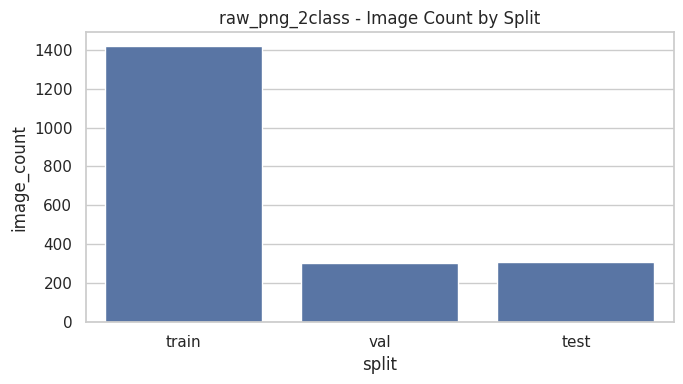

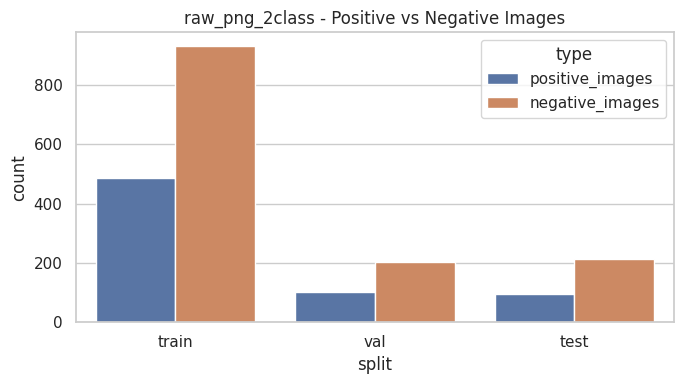

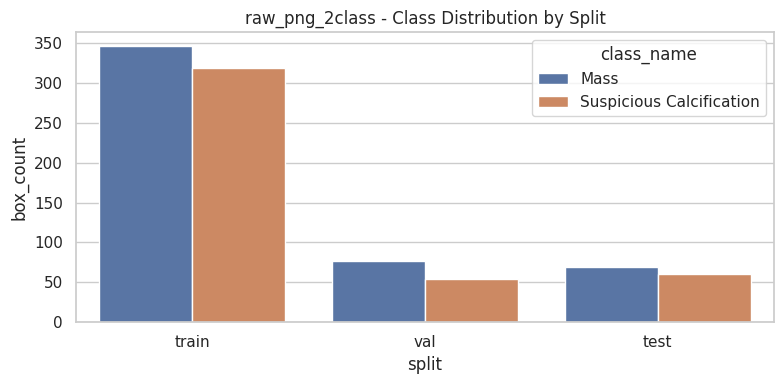

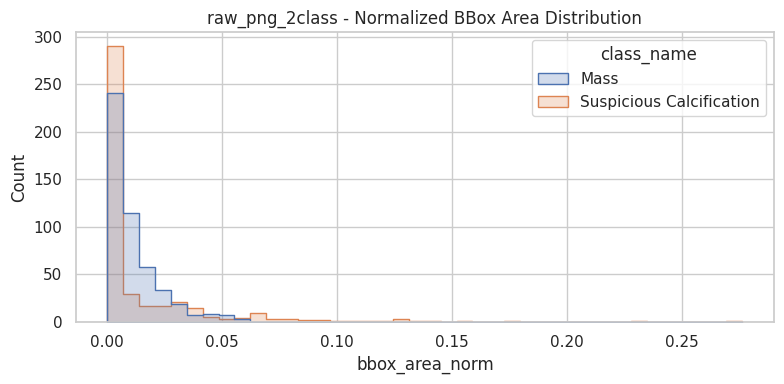

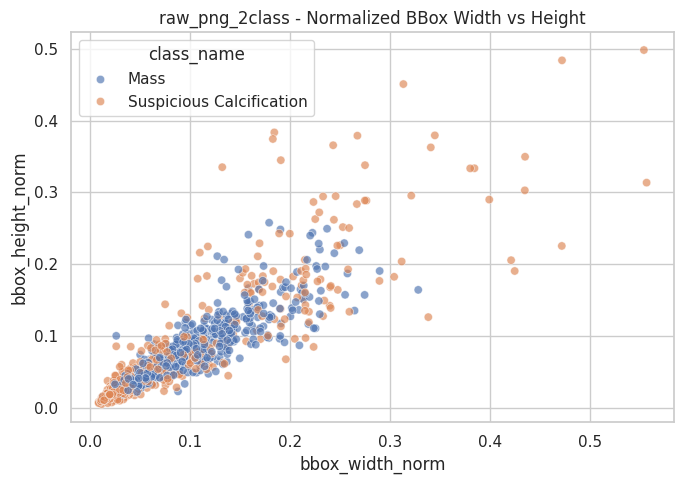

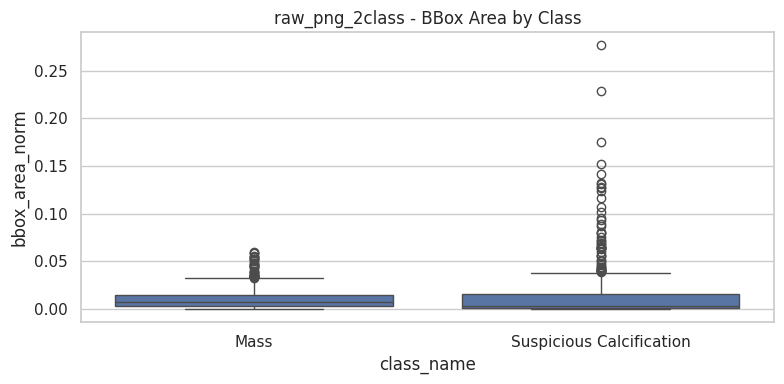

EDA Excel: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class/eda/raw_png_2class_EDA_SUMMARY.xlsx
EDA report: /content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class/eda/raw_png_2class_EDA_REPORT.md

DICOM -> PNG + EDA TAMAMLANDI
Raw prepared dataset:
/content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class

Crop+CLAHE prepared dataset:
/content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_crop_clahe_2class

Final report:
/content/drive/MyDrive/vindr_mammo/dataset/subsets/target2class_subset_v2_medium_balanced/prepared_dataset_reports/target2class_subset_v2_medium_balanced_PNG_PREPARATION_AND_EDA_REPORT.md

Raw data.yaml:
/content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class/data.yaml

Crop+CLAHE data.y

In [ ]:
# ============================================================
# VinDr-Mammo target2class_subset_v2_medium_balanced
# DICOM -> PNG + Raw Dataset + Crop/CLAHE Dataset + EDA
#
# Target classes:
#   0: Mass
#   1: Suspicious Calcification
#
# Same-box multi-label handling:
#   If same bbox has both Mass and Suspicious Calcification,
#   primary label = Mass
#
# Outputs:
#   1) raw PNG prepared dataset
#   2) crop + CLAHE prepared dataset
#   3) YOLO labels
#   4) COCO annotations
#   5) EDA tables, figures, visual checks, reports
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

!pip -q install pandas numpy matplotlib seaborn opencv-python pydicom tqdm pyyaml openpyxl

from pathlib import Path
from datetime import datetime
import os
import json
import shutil
import subprocess
import random
import warnings

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. Genel ayarlar
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/content/drive/MyDrive/vindr_mammo")
DATASET_BASE = PROJECT_ROOT / "dataset"

SUBSET_NAME = "target2class_subset_v2_medium_balanced"

SUBSET_DIR = DATASET_BASE / "subsets" / SUBSET_NAME
DRIVE_RAW_DICOM_DIR = DATASET_BASE / "raw" / SUBSET_NAME
LOCAL_RAW_DICOM_DIR = Path("/content/vindr_mammo_fast_raw") / SUBSET_NAME

LOCAL_PREPARED_BASE = Path("/content/vindr_prepared_datasets")
DRIVE_PREPARED_BASE = DATASET_BASE / "prepared_datasets"

RAW_DATASET_NAME = f"{SUBSET_NAME}_raw_png_2class"
CROP_CLAHE_DATASET_NAME = f"{SUBSET_NAME}_crop_clahe_2class"

LOCAL_RAW_PREPARED_DIR = LOCAL_PREPARED_BASE / RAW_DATASET_NAME
DRIVE_RAW_PREPARED_DIR = DRIVE_PREPARED_BASE / RAW_DATASET_NAME

LOCAL_CROP_PREPARED_DIR = LOCAL_PREPARED_BASE / CROP_CLAHE_DATASET_NAME
DRIVE_CROP_PREPARED_DIR = DRIVE_PREPARED_BASE / CROP_CLAHE_DATASET_NAME

MANIFEST_PATH = SUBSET_DIR / "subset_manifest.csv"
TARGET_FINDINGS_EXPLODED_PATH = SUBSET_DIR / "target_findings_exploded.csv"

TARGET_CLASSES = ["Mass", "Suspicious Calcification"]
CLASS_NAME_TO_ID = {
    "Mass": 0,
    "Suspicious Calcification": 1,
}
ID_TO_CLASS_NAME = {
    0: "Mass",
    1: "Suspicious Calcification",
}

# Aynı bbox hem Mass hem Calcification ise Mass seçilecek.
PRIMARY_PRIORITY = ["Mass", "Suspicious Calcification"]

# DICOM -> PNG ayarları
MAX_SIDE = 2048
LOW_PERCENTILE = 0.5
HIGH_PERCENTILE = 99.5

# Crop + CLAHE ayarları
CREATE_CROP_CLAHE_DATASET = False
CROP_MARGIN_RATIO = 0.035
MIN_BREAST_AREA_RATIO = 0.05
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

# Sync ayarı
SYNC_EVERY_N_IMAGES = 100
SKIP_SYNC_RAW_DICOM_TO_LOCAL = True

# Yeniden oluşturma ayarları
FORCE_REBUILD_RAW = False
FORCE_REBUILD_CROP_CLAHE = False

print("SUBSET_DIR:", SUBSET_DIR)
print("DRIVE_RAW_DICOM_DIR:", DRIVE_RAW_DICOM_DIR)
print("LOCAL_RAW_DICOM_DIR:", LOCAL_RAW_DICOM_DIR)
print("DRIVE_RAW_PREPARED_DIR:", DRIVE_RAW_PREPARED_DIR)
print("DRIVE_CROP_PREPARED_DIR:", DRIVE_CROP_PREPARED_DIR)

for p in [SUBSET_DIR, DRIVE_RAW_DICOM_DIR, MANIFEST_PATH, TARGET_FINDINGS_EXPLODED_PATH]:
    print(p, "exists:", p.exists())
    if not p.exists():
        raise FileNotFoundError(p)

# ------------------------------------------------------------
# 2. Drive'daki DICOM'ları local /content'e kopyala
# ------------------------------------------------------------

def rsync_dir(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-ah",
        "--info=progress2",
        f"{src}/",
        f"{dst}/"
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr[-4000:])
        raise RuntimeError(f"rsync başarısız: {src} -> {dst}")

    print(f"✅ Synced: {src} -> {dst}")

if not SKIP_SYNC_RAW_DICOM_TO_LOCAL:
    print("DICOM dosyaları Drive'dan local /content'e senkronize ediliyor...")
    rsync_dir(DRIVE_RAW_DICOM_DIR, LOCAL_RAW_DICOM_DIR)
else:
    print("DICOM local sync skipped; using Drive paths directly.")

# ------------------------------------------------------------
# 3. Manifest ve annotation dosyalarını oku
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_PATH)
target_findings = pd.read_csv(TARGET_FINDINGS_EXPLODED_PATH)

manifest["study_id"] = manifest["study_id"].astype(str)
manifest["image_id"] = manifest["image_id"].astype(str)

target_findings["study_id"] = target_findings["study_id"].astype(str)
target_findings["image_id"] = target_findings["image_id"].astype(str)

for col in ["xmin", "ymin", "xmax", "ymax"]:
    target_findings[col] = pd.to_numeric(target_findings[col], errors="coerce")

target_findings = target_findings[
    target_findings["category_list"].isin(TARGET_CLASSES)
].copy()

selected_image_ids = set(manifest["image_id"].astype(str))
target_findings = target_findings[
    target_findings["image_id"].isin(selected_image_ids)
].copy()

print("Manifest:", manifest.shape)
print("Target findings exploded:", target_findings.shape)
display(manifest.head())
display(target_findings.head())

# ------------------------------------------------------------
# 4. Multi-label bbox -> primary 2-class annotation
# ------------------------------------------------------------

bbox_key_cols = ["study_id", "image_id", "xmin", "ymin", "xmax", "ymax"]

def choose_primary_class(classes):
    classes = list(sorted(set(classes)))
    for c in PRIMARY_PRIORITY:
        if c in classes:
            return c
    return classes[0]

primary_rows = []

for key, group in target_findings.groupby(bbox_key_cols, dropna=False):
    class_list = sorted(set(group["category_list"].tolist()))
    primary_class = choose_primary_class(class_list)

    row = dict(zip(bbox_key_cols, key))
    row["target_classes_same_box"] = "|".join(class_list)
    row["n_target_classes_same_box"] = len(class_list)
    row["primary_class_name"] = primary_class
    row["primary_class_id"] = CLASS_NAME_TO_ID[primary_class]
    primary_rows.append(row)

primary_ann = pd.DataFrame(primary_rows)

primary_ann = primary_ann.merge(
    manifest[["image_id", "subset_split"]].drop_duplicates(),
    on="image_id",
    how="left"
)

if primary_ann["subset_split"].isna().any():
    raise RuntimeError("Bazı annotation satırları split alamadı.")

print("Exploded target labels:", len(target_findings))
print("Unique primary bboxes:", len(primary_ann))
print("Primary class distribution:")
display(primary_ann["primary_class_name"].value_counts().rename_axis("class_name").reset_index(name="count"))

multi_label_summary = (
    primary_ann["n_target_classes_same_box"]
    .value_counts()
    .sort_index()
    .rename_axis("n_target_classes_same_box")
    .reset_index(name="bbox_count")
)

display(multi_label_summary)

# ------------------------------------------------------------
# 5. Yardımcı fonksiyonlar
# ------------------------------------------------------------

def valid_dicom_path(row):
    rel = row.get("expected_relative_path", None)

    if isinstance(rel, str) and rel.strip():
        local_path = LOCAL_RAW_DICOM_DIR / rel
        drive_path = DRIVE_RAW_DICOM_DIR / rel
    else:
        local_path = LOCAL_RAW_DICOM_DIR / "images" / str(row["study_id"]) / f"{row['image_id']}.dicom"
        drive_path = DRIVE_RAW_DICOM_DIR / "images" / str(row["study_id"]) / f"{row['image_id']}.dicom"

    if local_path.exists() and local_path.stat().st_size > 1024:
        return local_path, "local"

    if drive_path.exists() and drive_path.stat().st_size > 1024:
        return drive_path, "drive"

    return local_path, "missing"


def dicom_to_uint8_png_array(dicom_path):
    ds = pydicom.dcmread(str(dicom_path), force=True)

    try:
        arr = apply_voi_lut(ds.pixel_array, ds)
    except Exception:
        arr = ds.pixel_array

    arr = np.asarray(arr)

    if arr.ndim > 2:
        arr = np.squeeze(arr)
        if arr.ndim > 2:
            arr = arr[0]

    arr = arr.astype(np.float32)

    photometric = str(getattr(ds, "PhotometricInterpretation", "")).upper()

    if photometric == "MONOCHROME1":
        arr = arr.max() - arr

    finite_mask = np.isfinite(arr)
    if not finite_mask.any():
        raise RuntimeError(f"Geçersiz pixel array: {dicom_path}")

    arr_valid = arr[finite_mask]

    lo = np.percentile(arr_valid, LOW_PERCENTILE)
    hi = np.percentile(arr_valid, HIGH_PERCENTILE)

    if hi <= lo:
        lo = arr_valid.min()
        hi = arr_valid.max()

    if hi <= lo:
        arr8 = np.zeros_like(arr, dtype=np.uint8)
    else:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
        arr8 = (arr * 255.0).clip(0, 255).astype(np.uint8)

    return arr8, ds


def resize_keep_aspect(img, max_side=2048):
    h, w = img.shape[:2]
    scale = min(max_side / max(h, w), 1.0)

    if scale == 1.0:
        return img, 1.0, 1.0

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    scale_x = new_w / w
    scale_y = new_h / h

    return resized, scale_x, scale_y


def clip_box(x1, y1, x2, y2, w, h):
    x1 = max(0.0, min(float(x1), w - 1))
    y1 = max(0.0, min(float(y1), h - 1))
    x2 = max(0.0, min(float(x2), w - 1))
    y2 = max(0.0, min(float(y2), h - 1))

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def xyxy_to_yolo(x1, y1, x2, y2, w, h):
    bw = x2 - x1
    bh = y2 - y1

    if bw <= 1 or bh <= 1:
        return None

    xc = x1 + bw / 2
    yc = y1 + bh / 2

    return xc / w, yc / h, bw / w, bh / h


def yolo_to_xyxy(cls, xc, yc, bw, bh, w, h):
    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    x2 = (xc + bw / 2) * w
    y2 = (yc + bh / 2) * h
    return x1, y1, x2, y2


def write_yolo_label(path, labels):
    path.parent.mkdir(parents=True, exist_ok=True)

    lines = []
    for lab in labels:
        lines.append(
            f"{int(lab['class_id'])} {lab['xc']:.8f} {lab['yc']:.8f} {lab['bw']:.8f} {lab['bh']:.8f}"
        )

    with open(path, "w", encoding="utf-8") as f:
        if lines:
            f.write("\n".join(lines) + "\n")


def read_yolo_label(path):
    path = Path(path)

    if not path.exists():
        return []

    txt = path.read_text().strip()

    if not txt:
        return []

    labels = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])
        labels.append({
            "class_id": cls,
            "xc": xc,
            "yc": yc,
            "bw": bw,
            "bh": bh,
        })

    return labels


def make_data_yaml(prepared_dir):
    data_yaml = {
        "path": str(prepared_dir),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": 2,
        "names": {
            0: "Mass",
            1: "Suspicious Calcification",
        },
    }

    with open(prepared_dir / "data.yaml", "w", encoding="utf-8") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)


def make_class_mapping(prepared_dir):
    mapping = {
        "class_to_id": CLASS_NAME_TO_ID,
        "id_to_class": {str(k): v for k, v in ID_TO_CLASS_NAME.items()},
        "primary_priority": PRIMARY_PRIORITY,
        "same_box_multilabel_rule": "Mass priority if same bbox has Mass and Suspicious Calcification",
    }

    with open(prepared_dir / "class_mapping.json", "w", encoding="utf-8") as f:
        json.dump(mapping, f, indent=4, ensure_ascii=False)


def sync_prepared_to_drive(local_prepared_dir, drive_prepared_dir):
    drive_prepared_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        "rsync",
        "-ah",
        "--info=progress2",
        f"{local_prepared_dir}/",
        f"{drive_prepared_dir}/"
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if result.returncode != 0:
        print(result.stderr[-4000:])
        raise RuntimeError("Prepared dataset sync başarısız.")

    print(f"✅ Prepared synced: {local_prepared_dir} -> {drive_prepared_dir}")


# ------------------------------------------------------------
# 6. Raw PNG prepared dataset oluştur
# ------------------------------------------------------------

def prepare_raw_png_dataset():
    ready_flag = DRIVE_RAW_PREPARED_DIR / "RAW_PNG_DATASET_READY.flag"

    if ready_flag.exists() and not FORCE_REBUILD_RAW:
        print("✅ Raw PNG dataset zaten hazır. Atlanıyor.")
        return

    print("🚀 Raw PNG 2-class dataset hazırlanıyor...")

    if FORCE_REBUILD_RAW:
        shutil.rmtree(LOCAL_RAW_PREPARED_DIR, ignore_errors=True)
        shutil.rmtree(DRIVE_RAW_PREPARED_DIR, ignore_errors=True)

    for base in [LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR]:
        for sub in [
            "images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test",
            "annotations", "logs", "eda/tables", "eda/figures", "visual_checks"
        ]:
            (base / sub).mkdir(parents=True, exist_ok=True)

    conversion_rows = []
    failed_rows = []
    dropped_box_rows = []

    ann_by_image = {
        image_id: group.copy()
        for image_id, group in primary_ann.groupby("image_id")
    }

    coco_by_split = {
        "train": {"images": [], "annotations": [], "categories": []},
        "val": {"images": [], "annotations": [], "categories": []},
        "test": {"images": [], "annotations": [], "categories": []},
    }

    categories = [
        {"id": 1, "name": "Mass", "supercategory": "finding"},
        {"id": 2, "name": "Suspicious Calcification", "supercategory": "finding"},
    ]

    for split in ["train", "val", "test"]:
        coco_by_split[split]["categories"] = categories

    image_id_counter = {"train": 1, "val": 1, "test": 1}
    ann_id_counter = {"train": 1, "val": 1, "test": 1}

    manifest_sorted = manifest.sort_values(["subset_split", "study_id", "image_id"]).reset_index(drop=True)

    converted_count = 0

    for _, row in tqdm(manifest_sorted.iterrows(), total=len(manifest_sorted), desc="DICOM -> raw PNG"):
        split = row["subset_split"]
        study_id = str(row["study_id"])
        image_id = str(row["image_id"])

        dicom_path, source_location = valid_dicom_path(row)

        out_img_path = LOCAL_RAW_PREPARED_DIR / "images" / split / f"{image_id}.png"
        out_lbl_path = LOCAL_RAW_PREPARED_DIR / "labels" / split / f"{image_id}.txt"

        try:
            if source_location == "missing":
                raise FileNotFoundError(f"DICOM missing: {dicom_path}")

            img8, ds = dicom_to_uint8_png_array(dicom_path)
            orig_h, orig_w = img8.shape[:2]

            resized, scale_x, scale_y = resize_keep_aspect(img8, MAX_SIDE)
            new_h, new_w = resized.shape[:2]

            out_img_path.parent.mkdir(parents=True, exist_ok=True)
            ok = cv2.imwrite(str(out_img_path), resized)

            if not ok:
                raise IOError(f"PNG yazılamadı: {out_img_path}")

            labels = []
            anns_img = ann_by_image.get(image_id, pd.DataFrame())

            coco_image_id = image_id_counter[split]
            image_id_counter[split] += 1

            coco_by_split[split]["images"].append({
                "id": coco_image_id,
                "file_name": f"images/{split}/{image_id}.png",
                "width": int(new_w),
                "height": int(new_h),
                "study_id": study_id,
                "original_image_id": image_id,
            })

            for _, ann in anns_img.iterrows():
                x1 = ann["xmin"] * scale_x
                y1 = ann["ymin"] * scale_y
                x2 = ann["xmax"] * scale_x
                y2 = ann["ymax"] * scale_y

                clipped = clip_box(x1, y1, x2, y2, new_w, new_h)

                if clipped is None:
                    dropped_box_rows.append({
                        "study_id": study_id,
                        "image_id": image_id,
                        "split": split,
                        "reason": "invalid_after_resize_clip",
                        "class_name": ann["primary_class_name"],
                        "xmin": ann["xmin"],
                        "ymin": ann["ymin"],
                        "xmax": ann["xmax"],
                        "ymax": ann["ymax"],
                    })
                    continue

                x1c, y1c, x2c, y2c = clipped
                yolo_box = xyxy_to_yolo(x1c, y1c, x2c, y2c, new_w, new_h)

                if yolo_box is None:
                    continue

                xc, yc, bw, bh = yolo_box
                class_id = int(ann["primary_class_id"])

                labels.append({
                    "class_id": class_id,
                    "xc": xc,
                    "yc": yc,
                    "bw": bw,
                    "bh": bh,
                })

                coco_ann_id = ann_id_counter[split]
                ann_id_counter[split] += 1

                coco_by_split[split]["annotations"].append({
                    "id": coco_ann_id,
                    "image_id": coco_image_id,
                    "category_id": class_id + 1,
                    "bbox": [float(x1c), float(y1c), float(x2c - x1c), float(y2c - y1c)],
                    "area": float((x2c - x1c) * (y2c - y1c)),
                    "iscrowd": 0,
                    "study_id": study_id,
                    "original_image_id": image_id,
                    "class_name": ID_TO_CLASS_NAME[class_id],
                })

            write_yolo_label(out_lbl_path, labels)

            conversion_rows.append({
                "study_id": study_id,
                "image_id": image_id,
                "split": split,
                "dicom_path": str(dicom_path),
                "source_location": source_location,
                "png_path": str(out_img_path),
                "orig_width": int(orig_w),
                "orig_height": int(orig_h),
                "new_width": int(new_w),
                "new_height": int(new_h),
                "scale_x": float(scale_x),
                "scale_y": float(scale_y),
                "n_labels": len(labels),
                "status": "success",
            })

            converted_count += 1

            if converted_count % SYNC_EVERY_N_IMAGES == 0:
                pd.DataFrame(conversion_rows).to_csv(
                    LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_conversion_log_live.csv",
                    index=False
                )
                sync_prepared_to_drive(LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR)

        except Exception as e:
            failed_rows.append({
                "study_id": study_id,
                "image_id": image_id,
                "split": split,
                "dicom_path": str(dicom_path),
                "source_location": source_location,
                "error": str(e),
            })

    conversion_df = pd.DataFrame(conversion_rows)
    failed_df = pd.DataFrame(failed_rows)
    dropped_df = pd.DataFrame(dropped_box_rows)

    conversion_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_conversion_log.csv", index=False)
    failed_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_failed_conversions.csv", index=False)
    dropped_df.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "raw_png_dropped_boxes.csv", index=False)

    for split, coco in coco_by_split.items():
        with open(LOCAL_RAW_PREPARED_DIR / "annotations" / f"instances_{split}.json", "w", encoding="utf-8") as f:
            json.dump(coco, f, indent=2, ensure_ascii=False)

    primary_ann.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "primary_2class_annotations.csv", index=False)
    multi_label_summary.to_csv(LOCAL_RAW_PREPARED_DIR / "logs" / "same_box_multilabel_summary.csv", index=False)

    make_data_yaml(LOCAL_RAW_PREPARED_DIR)
    make_class_mapping(LOCAL_RAW_PREPARED_DIR)

    sync_prepared_to_drive(LOCAL_RAW_PREPARED_DIR, DRIVE_RAW_PREPARED_DIR)

    (DRIVE_RAW_PREPARED_DIR / "RAW_PNG_DATASET_READY.flag").write_text(
        f"Raw PNG dataset created at {datetime.now().isoformat()}\n",
        encoding="utf-8"
    )

    print("Raw conversion success:", len(conversion_df))
    print("Raw conversion failed:", len(failed_df))

    if len(failed_df) > 0:
        display(failed_df.head())
        raise RuntimeError("Bazı DICOM dosyaları PNG'ye çevrilemedi. Log dosyasını kontrol et.")

prepare_raw_png_dataset()

# ------------------------------------------------------------
# 7. Crop + CLAHE dataset oluştur
# ------------------------------------------------------------

def find_breast_crop_box(gray):
    h, w = gray.shape[:2]

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    try:
        _, mask = cv2.threshold(
            blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
    except Exception:
        return 0, 0, w, h, "fallback_threshold_error"

    area_ratio = (mask > 0).sum() / (h * w)

    if area_ratio < MIN_BREAST_AREA_RATIO or area_ratio > 0.98:
        threshold_value = max(5, np.percentile(gray, 2))
        mask = (gray > threshold_value).astype(np.uint8) * 255

    kernel = np.ones((9, 9), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return 0, 0, w, h, "fallback_no_contour"

    largest = max(contours, key=cv2.contourArea)
    contour_area = cv2.contourArea(largest)

    if contour_area / (h * w) < MIN_BREAST_AREA_RATIO:
        return 0, 0, w, h, "fallback_small_contour"

    x, y, bw, bh = cv2.boundingRect(largest)

    margin_x = int(round(CROP_MARGIN_RATIO * w))
    margin_y = int(round(CROP_MARGIN_RATIO * h))

    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(w, x + bw + margin_x)
    y2 = min(h, y + bh + margin_y)

    if x2 <= x1 or y2 <= y1:
        return 0, 0, w, h, "fallback_invalid_crop"

    return x1, y1, x2, y2, "ok"


def apply_clahe(gray):
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_TILE_GRID_SIZE
    )
    return clahe.apply(gray)


def transform_labels_to_crop(labels, orig_w, orig_h, crop_box):
    crop_x1, crop_y1, crop_x2, crop_y2 = crop_box
    crop_w = crop_x2 - crop_x1
    crop_h = crop_y2 - crop_y1

    new_labels = []
    dropped = []

    for lab in labels:
        x1, y1, x2, y2 = yolo_to_xyxy(
            lab["class_id"],
            lab["xc"],
            lab["yc"],
            lab["bw"],
            lab["bh"],
            orig_w,
            orig_h
        )

        nx1 = x1 - crop_x1
        ny1 = y1 - crop_y1
        nx2 = x2 - crop_x1
        ny2 = y2 - crop_y1

        clipped = clip_box(nx1, ny1, nx2, ny2, crop_w, crop_h)

        if clipped is None:
            dropped.append({
                "class_id": lab["class_id"],
                "reason": "invalid_after_crop",
                "orig_xyxy": [x1, y1, x2, y2],
                "crop_box": crop_box,
            })
            continue

        x1c, y1c, x2c, y2c = clipped
        yolo_new = xyxy_to_yolo(x1c, y1c, x2c, y2c, crop_w, crop_h)

        if yolo_new is None:
            continue

        xc, yc, bw, bh = yolo_new

        new_labels.append({
            "class_id": lab["class_id"],
            "xc": min(max(xc, 0.0), 1.0),
            "yc": min(max(yc, 0.0), 1.0),
            "bw": min(max(bw, 0.0), 1.0),
            "bh": min(max(bh, 0.0), 1.0),
        })

    return new_labels, dropped


def make_coco_from_yolo(prepared_dir, split):
    image_dir = prepared_dir / "images" / split
    label_dir = prepared_dir / "labels" / split

    images = []
    annotations = []
    categories = [
        {"id": 1, "name": "Mass", "supercategory": "finding"},
        {"id": 2, "name": "Suspicious Calcification", "supercategory": "finding"},
    ]

    ann_id = 1

    for img_idx, image_path in enumerate(sorted(image_dir.glob("*.png")), start=1):
        image_id = image_path.stem
        img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        h, w = img.shape[:2]

        images.append({
            "id": img_idx,
            "file_name": f"images/{split}/{image_id}.png",
            "width": int(w),
            "height": int(h),
            "original_image_id": image_id,
        })

        labels = read_yolo_label(label_dir / f"{image_id}.txt")

        for lab in labels:
            x1, y1, x2, y2 = yolo_to_xyxy(
                lab["class_id"],
                lab["xc"],
                lab["yc"],
                lab["bw"],
                lab["bh"],
                w,
                h
            )

            clipped = clip_box(x1, y1, x2, y2, w, h)
            if clipped is None:
                continue

            x1c, y1c, x2c, y2c = clipped

            annotations.append({
                "id": ann_id,
                "image_id": img_idx,
                "category_id": int(lab["class_id"]) + 1,
                "bbox": [float(x1c), float(y1c), float(x2c - x1c), float(y2c - y1c)],
                "area": float((x2c - x1c) * (y2c - y1c)),
                "iscrowd": 0,
                "original_image_id": image_id,
                "class_name": ID_TO_CLASS_NAME[int(lab["class_id"])],
            })

            ann_id += 1

    return {
        "info": {
            "description": f"{prepared_dir.name} {split}",
            "created_at": datetime.now().isoformat(),
        },
        "licenses": [],
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }


def prepare_crop_clahe_dataset():
    if not CREATE_CROP_CLAHE_DATASET:
        print("CREATE_CROP_CLAHE_DATASET=False. Atlanıyor.")
        return

    ready_flag = DRIVE_CROP_PREPARED_DIR / "CROP_CLAHE_DATASET_READY.flag"

    if ready_flag.exists() and not FORCE_REBUILD_CROP_CLAHE:
        print("✅ Crop+CLAHE dataset zaten hazır. Atlanıyor.")
        return

    print("🚀 Crop + CLAHE 2-class dataset hazırlanıyor...")

    if FORCE_REBUILD_CROP_CLAHE:
        shutil.rmtree(LOCAL_CROP_PREPARED_DIR, ignore_errors=True)
        shutil.rmtree(DRIVE_CROP_PREPARED_DIR, ignore_errors=True)

    for base in [LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR]:
        for sub in [
            "images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test",
            "annotations", "logs", "eda/tables", "eda/figures", "visual_checks"
        ]:
            (base / sub).mkdir(parents=True, exist_ok=True)

    crop_rows = []
    dropped_rows = []
    processed_count = 0

    for split in ["train", "val", "test"]:
        src_img_dir = DRIVE_RAW_PREPARED_DIR / "images" / split
        src_lbl_dir = DRIVE_RAW_PREPARED_DIR / "labels" / split

        dst_img_dir = LOCAL_CROP_PREPARED_DIR / "images" / split
        dst_lbl_dir = LOCAL_CROP_PREPARED_DIR / "labels" / split

        for image_path in tqdm(sorted(src_img_dir.glob("*.png")), desc=f"Crop+CLAHE {split}"):
            image_id = image_path.stem

            gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

            if gray is None:
                continue

            h, w = gray.shape[:2]

            labels_old = read_yolo_label(src_lbl_dir / f"{image_id}.txt")

            crop_x1, crop_y1, crop_x2, crop_y2, crop_status = find_breast_crop_box(gray)

            cropped = gray[crop_y1:crop_y2, crop_x1:crop_x2]
            clahe_img = apply_clahe(cropped)

            labels_new, dropped = transform_labels_to_crop(
                labels_old,
                w,
                h,
                (crop_x1, crop_y1, crop_x2, crop_y2)
            )

            out_img_path = dst_img_dir / f"{image_id}.png"
            out_lbl_path = dst_lbl_dir / f"{image_id}.txt"

            out_img_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_img_path), clahe_img)

            write_yolo_label(out_lbl_path, labels_new)

            for d in dropped:
                d.update({
                    "split": split,
                    "image_id": image_id,
                })
                dropped_rows.append(d)

            crop_rows.append({
                "split": split,
                "image_id": image_id,
                "orig_width": w,
                "orig_height": h,
                "crop_x1": crop_x1,
                "crop_y1": crop_y1,
                "crop_x2": crop_x2,
                "crop_y2": crop_y2,
                "crop_width": crop_x2 - crop_x1,
                "crop_height": crop_y2 - crop_y1,
                "crop_status": crop_status,
                "old_label_count": len(labels_old),
                "new_label_count": len(labels_new),
                "dropped_label_count": len(dropped),
            })

            processed_count += 1

            if processed_count % SYNC_EVERY_N_IMAGES == 0:
                pd.DataFrame(crop_rows).to_csv(
                    LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_transform_log_live.csv",
                    index=False
                )
                sync_prepared_to_drive(LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR)

    crop_df = pd.DataFrame(crop_rows)
    dropped_df = pd.DataFrame(dropped_rows)

    crop_df.to_csv(LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_transform_log.csv", index=False)
    dropped_df.to_csv(LOCAL_CROP_PREPARED_DIR / "logs" / "crop_clahe_dropped_boxes.csv", index=False)

    for split in ["train", "val", "test"]:
        coco = make_coco_from_yolo(LOCAL_CROP_PREPARED_DIR, split)
        with open(LOCAL_CROP_PREPARED_DIR / "annotations" / f"instances_{split}.json", "w", encoding="utf-8") as f:
            json.dump(coco, f, indent=2, ensure_ascii=False)

    make_data_yaml(LOCAL_CROP_PREPARED_DIR)
    make_class_mapping(LOCAL_CROP_PREPARED_DIR)

    sync_prepared_to_drive(LOCAL_CROP_PREPARED_DIR, DRIVE_CROP_PREPARED_DIR)

    (DRIVE_CROP_PREPARED_DIR / "CROP_CLAHE_DATASET_READY.flag").write_text(
        f"Crop+CLAHE dataset created at {datetime.now().isoformat()}\n",
        encoding="utf-8"
    )

    print("Crop+CLAHE images:", len(crop_df))
    print("Dropped boxes:", len(dropped_df))
    display(crop_df.groupby("split")[["old_label_count", "new_label_count", "dropped_label_count"]].sum())

prepare_crop_clahe_dataset()

# ------------------------------------------------------------
# 8. EDA fonksiyonları
# ------------------------------------------------------------

def draw_gt_overlay(image_path, label_path, output_path, class_names):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        return False

    h, w = img.shape[:2]
    canvas = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    labels = read_yolo_label(label_path)

    for lab in labels:
        cls = int(lab["class_id"])
        x1, y1, x2, y2 = yolo_to_xyxy(
            cls,
            lab["xc"],
            lab["yc"],
            lab["bw"],
            lab["bh"],
            w,
            h
        )

        x1, y1, x2, y2 = map(lambda v: int(round(v)), [x1, y1, x2, y2])

        text = f"{cls}:{class_names[cls]}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            canvas,
            text,
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), canvas)

    return True


def run_eda(prepared_dir, dataset_label):
    prepared_dir = Path(prepared_dir)

    print(f"\n🔎 EDA başlıyor: {dataset_label}")
    print("Prepared dir:", prepared_dir)

    eda_dir = prepared_dir / "eda"
    table_dir = eda_dir / "tables"
    fig_dir = eda_dir / "figures"
    visual_dir = prepared_dir / "visual_checks"

    for p in [table_dir, fig_dir, visual_dir]:
        p.mkdir(parents=True, exist_ok=True)

    summary_rows = []
    image_rows = []
    box_rows = []

    for split in ["train", "val", "test"]:
        image_dir = prepared_dir / "images" / split
        label_dir = prepared_dir / "labels" / split

        image_paths = sorted(image_dir.glob("*.png"))

        class_counts = {0: 0, 1: 0}
        empty_labels = 0
        box_count = 0
        positive_images = 0

        for image_path in tqdm(image_paths, desc=f"EDA {dataset_label} {split}"):
            image_id = image_path.stem

            img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            h, w = img.shape[:2]

            labels = read_yolo_label(label_dir / f"{image_id}.txt")

            if len(labels) == 0:
                empty_labels += 1
            else:
                positive_images += 1

            image_rows.append({
                "dataset": dataset_label,
                "split": split,
                "image_id": image_id,
                "width": w,
                "height": h,
                "aspect_ratio": w / h,
                "n_boxes": len(labels),
                "is_positive": len(labels) > 0,
            })

            for lab in labels:
                cls = int(lab["class_id"])
                class_counts[cls] += 1
                box_count += 1

                x1, y1, x2, y2 = yolo_to_xyxy(
                    cls,
                    lab["xc"],
                    lab["yc"],
                    lab["bw"],
                    lab["bh"],
                    w,
                    h
                )

                bw_px = x2 - x1
                bh_px = y2 - y1
                area_px = bw_px * bh_px

                box_rows.append({
                    "dataset": dataset_label,
                    "split": split,
                    "image_id": image_id,
                    "class_id": cls,
                    "class_name": ID_TO_CLASS_NAME[cls],
                    "xmin": x1,
                    "ymin": y1,
                    "xmax": x2,
                    "ymax": y2,
                    "bbox_width_px": bw_px,
                    "bbox_height_px": bh_px,
                    "bbox_area_px": area_px,
                    "bbox_width_norm": lab["bw"],
                    "bbox_height_norm": lab["bh"],
                    "bbox_area_norm": lab["bw"] * lab["bh"],
                    "image_width": w,
                    "image_height": h,
                })

        summary_rows.append({
            "dataset": dataset_label,
            "split": split,
            "image_count": len(image_paths),
            "positive_images": positive_images,
            "negative_images": len(image_paths) - positive_images,
            "positive_image_rate": positive_images / max(len(image_paths), 1),
            "empty_label_files": empty_labels,
            "box_count": box_count,
            "Mass_boxes": class_counts[0],
            "Suspicious_Calcification_boxes": class_counts[1],
        })

    summary_df = pd.DataFrame(summary_rows)
    image_df = pd.DataFrame(image_rows)
    box_df = pd.DataFrame(box_rows)

    summary_df.to_csv(table_dir / "eda_split_summary.csv", index=False)
    image_df.to_csv(table_dir / "eda_image_stats.csv", index=False)
    box_df.to_csv(table_dir / "eda_bbox_stats.csv", index=False)

    print("Split summary:")
    display(summary_df)

    if len(box_df) > 0:
        print("BBox descriptive stats:")
        display(
            box_df.groupby("class_name")[
                ["bbox_width_px", "bbox_height_px", "bbox_area_px", "bbox_area_norm"]
            ].describe()
        )

    # -----------------------------
    # Grafikler
    # -----------------------------

    plt.figure(figsize=(7, 4))
    sns.barplot(data=summary_df, x="split", y="image_count")
    plt.title(f"{dataset_label} - Image Count by Split")
    plt.tight_layout()
    plt.savefig(fig_dir / "image_count_by_split.png", dpi=180)
    plt.show()
    plt.close()

    posneg = summary_df.melt(
        id_vars=["split"],
        value_vars=["positive_images", "negative_images"],
        var_name="type",
        value_name="count"
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=posneg, x="split", y="count", hue="type")
    plt.title(f"{dataset_label} - Positive vs Negative Images")
    plt.tight_layout()
    plt.savefig(fig_dir / "positive_negative_images_by_split.png", dpi=180)
    plt.show()
    plt.close()

    class_split = summary_df[["split", "Mass_boxes", "Suspicious_Calcification_boxes"]].melt(
        id_vars=["split"],
        var_name="class_name",
        value_name="box_count"
    )

    class_split["class_name"] = class_split["class_name"].replace({
        "Mass_boxes": "Mass",
        "Suspicious_Calcification_boxes": "Suspicious Calcification"
    })

    plt.figure(figsize=(8, 4))
    sns.barplot(data=class_split, x="split", y="box_count", hue="class_name")
    plt.title(f"{dataset_label} - Class Distribution by Split")
    plt.tight_layout()
    plt.savefig(fig_dir / "class_distribution_by_split.png", dpi=180)
    plt.show()
    plt.close()

    if len(box_df) > 0:
        plt.figure(figsize=(8, 4))
        sns.histplot(data=box_df, x="bbox_area_norm", hue="class_name", bins=40, element="step")
        plt.title(f"{dataset_label} - Normalized BBox Area Distribution")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_area_norm_distribution.png", dpi=180)
        plt.show()
        plt.close()

        plt.figure(figsize=(7, 5))
        sns.scatterplot(
            data=box_df,
            x="bbox_width_norm",
            y="bbox_height_norm",
            hue="class_name",
            alpha=0.65
        )
        plt.title(f"{dataset_label} - Normalized BBox Width vs Height")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_width_height_scatter.png", dpi=180)
        plt.show()
        plt.close()

        plt.figure(figsize=(8, 4))
        sns.boxplot(data=box_df, x="class_name", y="bbox_area_norm")
        plt.title(f"{dataset_label} - BBox Area by Class")
        plt.tight_layout()
        plt.savefig(fig_dir / "bbox_area_by_class_boxplot.png", dpi=180)
        plt.show()
        plt.close()

    # -----------------------------
    # Görsel kontroller
    # -----------------------------

    rng = np.random.default_rng(SEED)
    visual_rows = []

    for split in ["train", "val", "test"]:
        image_dir = prepared_dir / "images" / split
        label_dir = prepared_dir / "labels" / split

        label_paths = sorted(label_dir.glob("*.txt"))

        positive_ids = []
        negative_ids = []

        for lp in label_paths:
            if lp.read_text().strip():
                positive_ids.append(lp.stem)
            else:
                negative_ids.append(lp.stem)

        chosen_pos = rng.choice(
            positive_ids,
            size=min(12, len(positive_ids)),
            replace=False
        ).tolist() if positive_ids else []

        chosen_neg = rng.choice(
            negative_ids,
            size=min(4, len(negative_ids)),
            replace=False
        ).tolist() if negative_ids else []

        for image_id in chosen_pos + chosen_neg:
            img_path = image_dir / f"{image_id}.png"
            lbl_path = label_dir / f"{image_id}.txt"
            out_path = visual_dir / f"{dataset_label}_{split}_{image_id}_gt.png"

            saved = draw_gt_overlay(img_path, lbl_path, out_path, ID_TO_CLASS_NAME)

            visual_rows.append({
                "dataset": dataset_label,
                "split": split,
                "image_id": image_id,
                "n_boxes": len(read_yolo_label(lbl_path)),
                "visual_path": str(out_path),
                "saved": saved,
            })

    visual_df = pd.DataFrame(visual_rows)
    visual_df.to_csv(table_dir / "visual_check_index.csv", index=False)

    # -----------------------------
    # Excel + Markdown report
    # -----------------------------

    excel_path = eda_dir / f"{dataset_label}_EDA_SUMMARY.xlsx"

    with pd.ExcelWriter(excel_path) as writer:
        summary_df.to_excel(writer, sheet_name="split_summary", index=False)
        image_df.to_excel(writer, sheet_name="image_stats", index=False)
        box_df.to_excel(writer, sheet_name="bbox_stats", index=False)
        visual_df.to_excel(writer, sheet_name="visual_checks", index=False)

    report_path = eda_dir / f"{dataset_label}_EDA_REPORT.md"

    if len(box_df) > 0:
        box_class_summary = (
            box_df.groupby("class_name")
            .agg(
                count=("class_name", "count"),
                mean_width_norm=("bbox_width_norm", "mean"),
                mean_height_norm=("bbox_height_norm", "mean"),
                mean_area_norm=("bbox_area_norm", "mean"),
                median_area_norm=("bbox_area_norm", "median"),
                mean_area_px=("bbox_area_px", "mean"),
                median_area_px=("bbox_area_px", "median"),
            )
            .reset_index()
        )
    else:
        box_class_summary = pd.DataFrame()

    report_text = f"""# {dataset_label} EDA Report

## Dataset

Prepared directory:

`{prepared_dir}`

## Split Summary

{summary_df.to_markdown(index=False)}

## BBox Class Summary

{box_class_summary.to_markdown(index=False) if len(box_class_summary) else "No boxes found."}

## Notes

- Classes:
  - 0: Mass
  - 1: Suspicious Calcification
- Same-box Mass + Suspicious Calcification annotations are converted to primary label using Mass priority.
- Empty label files are kept for negative images.
- COCO annotations are available under `annotations/`.
- YOLO labels are available under `labels/`.
"""

    report_path.write_text(report_text, encoding="utf-8")

    print("EDA Excel:", excel_path)
    print("EDA report:", report_path)

    return summary_df, image_df, box_df, visual_df

# Raw EDA
raw_summary_df, raw_image_df, raw_box_df, raw_visual_df = run_eda(
    DRIVE_RAW_PREPARED_DIR,
    "raw_png_2class"
)

# Crop+CLAHE EDA
if CREATE_CROP_CLAHE_DATASET:
    crop_summary_df, crop_image_df, crop_box_df, crop_visual_df = run_eda(
        DRIVE_CROP_PREPARED_DIR,
        "crop_clahe_2class"
    )

# ------------------------------------------------------------
# 9. Final özet raporu
# ------------------------------------------------------------

FINAL_REPORT_DIR = SUBSET_DIR / "prepared_dataset_reports"
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

final_report_path = FINAL_REPORT_DIR / f"{SUBSET_NAME}_PNG_PREPARATION_AND_EDA_REPORT.md"

raw_primary_dist = (
    raw_box_df["class_name"].value_counts()
    .rename_axis("class_name")
    .reset_index(name="box_count")
)

report_text = f"""# {SUBSET_NAME} PNG Preparation and EDA Report

## Purpose

This report summarizes the DICOM-to-PNG conversion and EDA process for the two-class VinDr-Mammo subset.

Target classes:

- Mass
- Suspicious Calcification

## Annotation Policy

The original target annotation table contains exploded target labels.
For model training, annotations were converted into a primary 2-class detection format.

Primary rule:

- If the same bbox contains both Mass and Suspicious Calcification, the primary label is set to Mass.
- Otherwise, the original target class is used.

## Raw PNG Dataset

Prepared dataset:

`{DRIVE_RAW_PREPARED_DIR}`

### Raw Split Summary

{raw_summary_df.to_markdown(index=False)}

### Raw Primary Class Distribution

{raw_primary_dist.to_markdown(index=False)}

## Crop + CLAHE Dataset

Prepared dataset:

`{DRIVE_CROP_PREPARED_DIR if CREATE_CROP_CLAHE_DATASET else "Not created"}`

## Important Files

Raw dataset:
- `{DRIVE_RAW_PREPARED_DIR / "data.yaml"}`
- `{DRIVE_RAW_PREPARED_DIR / "annotations"}`
- `{DRIVE_RAW_PREPARED_DIR / "eda"}`

Crop+CLAHE dataset:
- `{DRIVE_CROP_PREPARED_DIR / "data.yaml"}`
- `{DRIVE_CROP_PREPARED_DIR / "annotations"}`
- `{DRIVE_CROP_PREPARED_DIR / "eda"}`

## Next Steps

Recommended experiments:

1. YOLOv8 raw image 2-class baseline.
2. YOLOv8 crop+CLAHE 2-class baseline.
3. Faster R-CNN on the better preprocessing branch.
4. Confidence/NMS threshold optimization.
5. Patch/tile-based high-resolution experiment, especially for Suspicious Calcification.
"""

final_report_path.write_text(report_text, encoding="utf-8")

print("\n" + "=" * 90)
print("DICOM -> PNG + EDA TAMAMLANDI")
print("=" * 90)

print("Raw prepared dataset:")
print(DRIVE_RAW_PREPARED_DIR)

print("\nCrop+CLAHE prepared dataset:")
print(DRIVE_CROP_PREPARED_DIR)

print("\nFinal report:")
print(final_report_path)

print("\nRaw data.yaml:")
print(DRIVE_RAW_PREPARED_DIR / "data.yaml")

print("\nCrop+CLAHE data.yaml:")
print(DRIVE_CROP_PREPARED_DIR / "data.yaml")

In [ ]:
#!/usr/bin/env python3
"""
Dataset visualization for VinDr-style detection datasets.

Usage:
    python visualize_dataset.py
"""

from pathlib import Path
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
random.seed(42)
np.random.seed(42)

# ROOT_DIR = Path("/content/vindr_prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class") # Original incorrect path
ROOT_DIR = Path("/content/drive/MyDrive/vindr_mammo/dataset/prepared_datasets/target2class_subset_v2_medium_balanced_raw_png_2class") # Corrected path
OUTPUT_DIR = Path("/content/vindr_visualization_report")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {0: "Mass", 1: "Suspicious Calcification"}
SPLITS = ["train", "val", "test"]


def read_yolo_label(path):
    path = Path(path)
    if not path.exists():
        return []
    text = path.read_text().strip()
    if not text:
        return []
    labels = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        class_id = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:])
        labels.append({"class_id": class_id, "xc": xc, "yc": yc, "bw": bw, "bh": bh})
    return labels


def yolo_to_xyxy(label, width, height):
    xc, yc, bw, bh = label["xc"], label["yc"], label["bw"], label["bh"]
    x1 = (xc - bw / 2.0) * width
    y1 = (yc - bh / 2.0) * height
    x2 = (xc + bw / 2.0) * width
    y2 = (yc + bh / 2.0) * height
    return x1, y1, x2, y2


def overlay_boxes(image, labels):
    canvas = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    for lab in labels:
        x1, y1, x2, y2 = map(int, map(round, yolo_to_xyxy(lab, image.shape[1], image.shape[0])))
        color = (0, 255, 0) if lab["class_id"] == 0 else (255, 128, 0)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            canvas,
            CLASS_NAMES[lab["class_id"]],
            (x1, max(20, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )
    return canvas


def gather_stats():
    image_stats = []
    box_stats = []

    for split in SPLITS:
        img_dir = ROOT_DIR / "images" / split
        lbl_dir = ROOT_DIR / "labels" / split
        image_paths = sorted(img_dir.glob("*.png"))

        for image_path in image_paths:
            labels = read_yolo_label(lbl_dir / f"{image_path.stem}.txt")
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue
            h, w = image.shape[:2]

            image_stats.append({
                "split": split,
                "image_id": image_path.stem,
                "width": w,
                "height": h,
                "aspect_ratio": w / h if h else 0.0,
                "n_boxes": len(labels),
                "has_boxes": len(labels) > 0,
            })

            for lab in labels:
                x1, y1, x2, y2 = yolo_to_xyxy(lab, w, h)
                box_area = max(0.0, (x2 - x1) * (y2 - y1))
                box_stats.append({
                    "split": split,
                    "image_id": image_path.stem,
                    "class_id": lab["class_id"],
                    "class_name": CLASS_NAMES[lab["class_id"]],
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "width_px": max(0.0, x2 - x1),
                    "height_px": max(0.0, y2 - y1),
                    "area_px": box_area,
                    "width_norm": lab["bw"],
                    "height_norm": lab["bh"],
                    "area_norm": lab["bw"] * lab["bh"],
                    "center_x_norm": lab["xc"],
                    "center_y_norm": lab["yc"],
                })

    image_df = pd.DataFrame(image_stats)
    box_df = pd.DataFrame(box_stats)
    image_df.to_csv(OUTPUT_DIR / "image_stats.csv", index=False)
    box_df.to_csv(OUTPUT_DIR / "box_stats.csv", index=False)
    return image_df, box_df


def plot_counts(image_df, box_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.countplot(data=image_df, x="split", ax=axes[0, 0])
    axes[0, 0].set_title("Image Count by Split")

    summary = image_df.groupby(["split", "has_boxes"]).size().reset_index(name="count")
    summary["type"] = summary["has_boxes"].map({True: "Positive", False: "Negative"})
    sns.barplot(data=summary, x="split", y="count", hue="type", ax=axes[0, 1])
    axes[0, 1].set_title("Positive vs Negative Images")

    class_counts = box_df["class_name"].value_counts().reset_index()
    class_counts.columns = ["class_name", "box_count"]
    sns.barplot(data=class_counts, x="class_name", y="box_count", ax=axes[1, 0])
    axes[1, 0].set_title("Total Box Count by Class")
    axes[1, 0].tick_params(axis="x", rotation=20)

    sns.histplot(data=image_df, x="aspect_ratio", hue="split", kde=True, ax=axes[1, 1])
    axes[1, 1].set_title("Image Aspect Ratio Distribution")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "dataset_counts_overview.png", dpi=180)
    plt.close()


def plot_box_distributions(box_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(data=box_df, x="area_norm", hue="class_name", bins=40, element="step", ax=axes[0, 0])
    axes[0, 0].set_title("Normalized Box Area by Class")

    sns.histplot(data=box_df, x="width_norm", hue="class_name", bins=40, element="step", ax=axes[0, 1])
    axes[0, 1].set_title("Normalized Box Width by Class")

    sns.histplot(data=box_df, x="height_norm", hue="class_name", bins=40, element="step", ax=axes[1, 0])
    axes[1, 0].set_title("Normalized Box Height by Class")

    sns.scatterplot(
        data=box_df,
        x="width_norm",
        y="height_norm",
        hue="class_name",
        alpha=0.6,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title("Box Width vs Height (Normalized)")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "box_distribution_plots.png", dpi=180)
    plt.close()


def plot_center_heatmap(box_df):
    heatmap_data = box_df.copy()
    heatmap_data["cx_bin"] = pd.cut(heatmap_data["center_x_norm"], bins=30, labels=False)
    heatmap_data["cy_bin"] = pd.cut(heatmap_data["center_y_norm"], bins=30, labels=False)
    heatmap_pivot = (
        heatmap_data.groupby(["cy_bin", "cx_bin"]).size()
        .unstack(fill_value=0)
        .sort_index(ascending=False)
    )

    plt.figure(figsize=(8, 8))
    sns.heatmap(heatmap_pivot, cmap="viridis")
    plt.title("Bounding Box Center Heatmap")
    plt.xlabel("Normalized X position")
    plt.ylabel("Normalized Y position")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bbox_center_heatmap.png", dpi=180)
    plt.close()


def save_example_images(image_df, box_df, n_examples=5):
    examples = []
    for class_id in [0, 1]:
        class_images = box_df[box_df["class_id"] == class_id]["image_id"].unique().tolist()
        if class_images:
            examples.extend([(class_id, iid) for iid in random.sample(class_images, min(n_examples, len(class_images)))])
    negative_images = image_df[(image_df["has_boxes"] == False)]["image_id"].unique().tolist()
    examples.extend([(-1, iid) for iid in random.sample(negative_images, min(n_examples, len(negative_images)))])

    saved_count = 0
    for class_id, image_id in examples:
        for split in SPLITS:
            img_path = ROOT_DIR / "images" / split / f"{image_id}.png"
            lbl_path = ROOT_DIR / "labels" / split / f"{image_id}.txt"
            if not img_path.exists():
                continue
            image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            labels = read_yolo_label(lbl_path)
            overlay = overlay_boxes(image, labels)
            tag = "negative" if class_id == -1 else CLASS_NAMES[class_id].replace(" ", "_")
            save_path = OUTPUT_DIR / f"example_{tag}_{split}_{image_id}.png"
            cv2.imwrite(str(save_path), overlay)
            saved_count += 1
            break
    print(f"Saved {saved_count} example images to {OUTPUT_DIR}")


def make_report(image_df, box_df):
    summary = []
    for split in SPLITS:
        split_images = image_df[image_df["split"] == split]
        split_boxes = box_df[box_df["split"] == split]
        summary.append({
            "split": split,
            "image_count": len(split_images),
            "positive_images": int(split_images["has_boxes"].sum()),
            "negative_images": int(len(split_images) - split_images["has_boxes"].sum()),
            "total_boxes": len(split_boxes),
            "mean_boxes_per_image": split_images["n_boxes"].mean(),
            "median_boxes_per_image": split_images["n_boxes"].median(),
        })

    report_df = pd.DataFrame(summary)
    report_df.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)

    with open(OUTPUT_DIR / "EDA_REPORT.md", "w", encoding="utf-8") as f:
        f.write("# Dataset Visualization Report\n\n")
        f.write("## Split summary\n\n")
        f.write(report_df.to_markdown(index=False))
        f.write("\n\n")
        f.write("## Notes\n\n")
        f.write(
            "- Examine the count imbalance between `Mass` and `Suspicious Calcification`.\n"
            "- Review the normalized bbox area distribution to understand small-object difficulty.\n"
            "- Inspect the center heatmap to see whether lesions concentrate in particular image regions.\n"
            "- Use the saved examples to show representative positive and negative cases.\n"
        )


def main():
    image_df, box_df = gather_stats()
    plot_counts(image_df, box_df)
    plot_box_distributions(box_df)
    plot_center_heatmap(box_df)
    save_example_images(image_df, box_df)
    make_report(image_df, box_df)
    print("Visualization report created at:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

Saved 15 example images to /content/vindr_visualization_report
Visualization report created at: /content/vindr_visualization_report
